# **Audience** **Decode** **- Machine Learning Project**



This project explores how **user behavior** and **movie characteristics** can be combined to build an interpretable, data-driven recommendation system.

The dataset (`viewer_interactions.db`) is a relational SQLite database with four main tables: **viewer_ratings** (individual user-movie interactions), **movies** (metadata), **user_statistics** (pre-aggregated user behavioral metrics), and **movie_statistics** (item-level summary statistics).

The analysis follows a structured pipeline:

1. **Exploratory Data Analysis**, univariate distributions and correlation analysis for user and movie features.
2. **Preprocessing**, cleaning, imputation, outlier removal, feature engineering, and scaling.
3. **User clustering**, K-Means, MiniBatch K-Means, and BIRCH are trained and compared on the user feature matrix.
4. **Movie clustering**, the same three algorithms are applied to the movie feature matrix.
5. **Cluster interpretation**, user-cluster to movie-cluster affinity is estimated and visualized as a preference matrix.
6. **Recommendation**, a scoring function generates personalized Top-N suggestions for any user in the dataset.
7. **Evaluation**, the system is assessed with score calibration metrics (RMSE, MAE, Pearson correlation) and ranking metrics (Precision@k, Recall@k, Hit Rate@k).

# **0. SET UP & DATA LOADING**

This section sets up the working environment and loads the source data. We import all required libraries, establish a connection to `viewer_interactions.db`, verify the available tables, and read each table into a Pandas DataFrame. A shape check confirms that the data has loaded correctly before any analysis begins.

We import the required libraries and open a connection to `viewer_interactions.db`. The `sqlite3` module handles the database connection. `pandas` and `numpy` cover data manipulation, `matplotlib` and `seaborn` handle visualization, and `scikit-learn` provides `KMeans`, `MiniBatchKMeans`, `Birch`, `StandardScaler`, and `PCA`. As a quick sanity check, we list the available tables to confirm the database structure matches what is expected.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.decomposition import PCA

db_path = "viewer_interactions.db"

conn = sqlite3.connect(db_path)

# Show available tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in the database viewer_interactions"":")
for name in tables["name"]:
    print(name)

Tables in the database viewer_interactions:
viewer_ratings
movies
user_statistics
movie_statistics
data_dictionary


**Interpretation of the results.**

If the printed list includes all expected tables (`viewer_ratings`, `movies`, `user_statistics`, `movie_statistics`, `data_dictionary`), the environment is correctly configured. A mismatch at this stage would indicate a wrong database path or a structural change in the file that needs to be resolved before continuing.

We load each table in full using `pd.read_sql()` and close the database connection immediately once all data is in memory. Printing the shape of each DataFrame confirms row counts: `viewer_ratings` should be by far the largest (one row per rating), while the statistics tables are compact summaries with one row per user or movie.

In [2]:
# Load each table from the database into a separate DataFrame
viewer_ratings   = pd.read_sql("SELECT * FROM viewer_ratings;", conn)
movies           = pd.read_sql("SELECT * FROM movies;", conn)
user_statistics  = pd.read_sql("SELECT * FROM user_statistics;", conn)
movie_statistics = pd.read_sql("SELECT * FROM movie_statistics;", conn)
data_dictionary  = pd.read_sql("SELECT * FROM data_dictionary;", conn)

# Close the connection once all data is in memory
conn.close()

# Print table shapes as a quick sanity check
print("\nShapes of main tables:")
print("viewer_ratings  : ", viewer_ratings.shape)
print("movies          :", movies.shape)
print("user_statistics :", user_statistics.shape)
print("movie_statistics:", movie_statistics.shape)


Shapes of main tables:
viewer_ratings  :  (4025000, 5)
movies          : (18008, 3)
user_statistics : (438780, 10)
movie_statistics: (16015, 11)


**Interpretation of the results.**

The printed shapes confirm that all five tables loaded correctly. `viewer_ratings` is the largest, as expected for an interaction-level log. The statistics tables (`user_statistics`, `movie_statistics`) are much smaller, reflecting pre-aggregated summaries. From this point on, the analysis operates exclusively on these in-memory DataFrames.

# **1.1 EDA - USER STATISTICS**

This section characterizes the `user_statistics` table across four behavioral dimensions:

1. **Activity volume** (`total_ratings`), how many ratings each user has contributed.
2. **Rating tendency** (`avg_rating`), each user's typical scoring level.
3. **Rating variability** (`std_rating`), how consistently or erratically a user rates items.
4. **Temporal persistence** (`activity_days`), how long a user remains active on the platform.

Because user activity follows a heavy-tailed distribution, log-scaled visualizations are used where appropriate. The section closes with a **correlation heatmap** to detect redundant features and inform later decisions on which variables to include in clustering.

We begin with a structural check of the `user_statistics` table, printing its dimensions and displaying the first few rows. This confirms the number of available user profiles and verifies that the expected feature columns are present before plotting any distributions.

In [3]:
# 1.1.1 Dataset overview

print("User statistics dataset shape:", user_statistics.shape)
user_statistics.head()

User statistics dataset shape: (438780, 10)


,customer_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_movies,first_rating_date,last_rating_date,activity_days
0,1965326,8.0,3.250000,0.886405,2.0,5.0,8.0,2004-08-11,2005-06-06,299.0
1,506434,1.0,4.000000,NaN,4.0,4.0,1.0,2005-08-02,2005-08-02,0.0
2,1365167,3.0,4.666667,0.577350,4.0,5.0,3.0,2004-11-16,2005-01-19,64.0
3,396632,2.0,NaN,0.000000,4.0,4.0,2.0,2004-07-07,2004-07-07,0.0
4,260614,3.0,4.333333,0.577350,4.0,5.0,3.0,2004-03-02,2004-10-13,NaN


**Interpretation of the results.**

The shape output shows the total number of user profiles. The column preview confirms that the expected behavioral summary fields (`total_ratings`, `avg_rating`, `std_rating`, `unique_movies`, `activity_days`) are present and correctly loaded, with no immediate structural issues.

We examine the distribution of `total_ratings`, which captures how actively each user interacts with the platform. Because a small set of power users generates a disproportionate share of ratings, we visualize the data at three levels: a **linear-scale histogram** to show the bulk, a **log-scale histogram** to reveal the heavy tail, and a **boxplot** to highlight extreme outliers.

Mean: 9.287267807149489
Median: 4.0


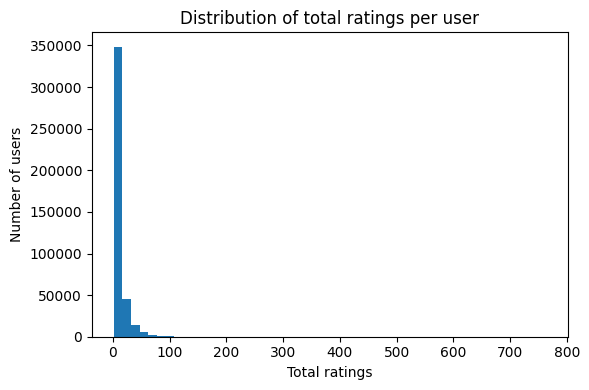

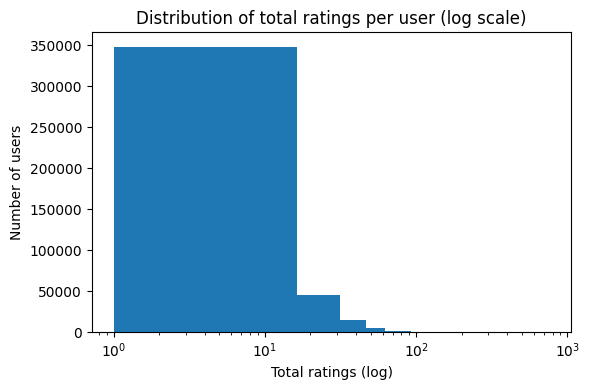

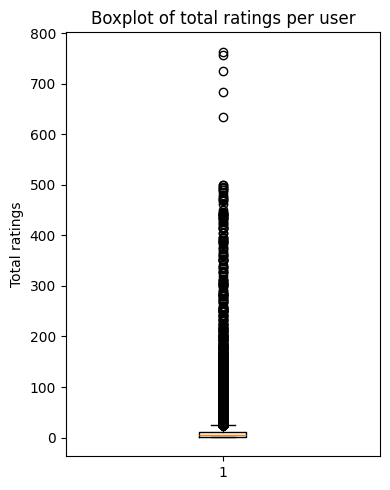

In [4]:
# UNIVARIATE DISTRIBUTIONS (USERS)
# 1.1.2 Distribution: total number of ratings per user

data = user_statistics["total_ratings"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.title("Distribution of total ratings per user")
plt.xlabel("Total ratings")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.xscale("log")
plt.title("Distribution of total ratings per user (log scale)")
plt.xlabel("Total ratings (log)")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("Boxplot of total ratings per user")
plt.ylabel("Total ratings")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

The distribution of `total_ratings` is **highly right-skewed**. Key observations:

- The **mean is substantially higher than the median**, confirming strong positive skew driven by a small number of power users.
- The **log-scale histogram** reveals the full extent of the heavy tail, a pattern typical of user-generated content platforms.
- The **boxplot** shows many extreme outliers, confirming that a small group accounts for a disproportionate share of total interaction volume.

This skew motivates the use of log-transformed features and justifies the conservative 99th-percentile outlier filter applied in Section 2.

We analyze `avg_rating`, which summarizes each user's overall rating tendency. Compared to activity variables, we expect a more **compact and approximately symmetric distribution**, since most users rate within a moderate range. Users with very few ratings may show extreme averages due to limited sampling.

Mean: 3.6321948158680644
Median: 3.6875


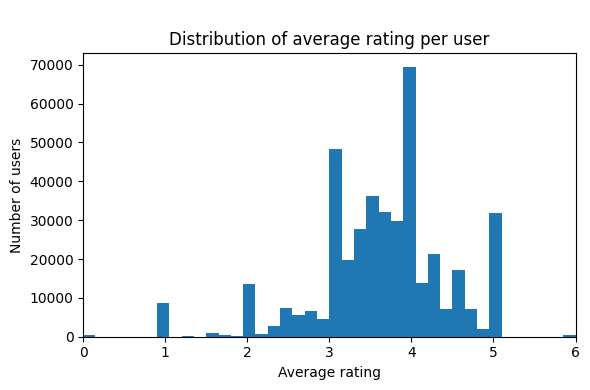

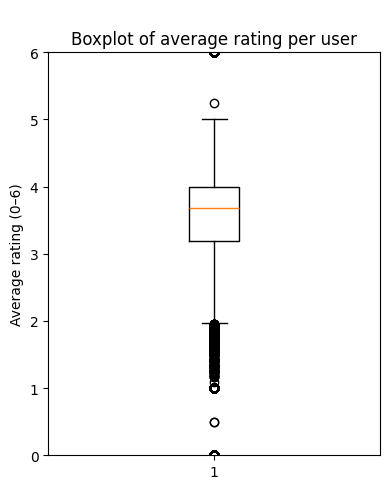

In [5]:
# 1.1.3 Distribution: average rating per user

data = user_statistics["avg_rating"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=40, range=(0, 6))
plt.title("\nDistribution of average rating per user")
plt.xlabel("Average rating")
plt.ylabel("Number of users")
plt.xlim(0, 6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("\nBoxplot of average rating per user")
plt.ylabel("Average rating (0–6)")
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

**Interpretation of the results.**

User average ratings are **concentrated around mid-to-high values**, with mean and median close together. Key observations:

- The distribution is **compact** compared to activity features, indicating limited global rating bias across the user population.
- The boxplot reveals a small number of **extreme raters** at both ends, typically associated with users who have rated very few items.
- Near-symmetry suggests that `avg_rating` alone is not a strong differentiator between most users, but it adds meaningful information when combined with variability features.

We examine `std_rating`, which measures how variable a user's ratings are across items. This feature distinguishes **consistent raters**, who reliably assign similar scores regardless of content, from **erratic raters**, whose evaluations fluctuate more strongly.

Mean: 0.8976237179922618
Median: 0.8677594571571442


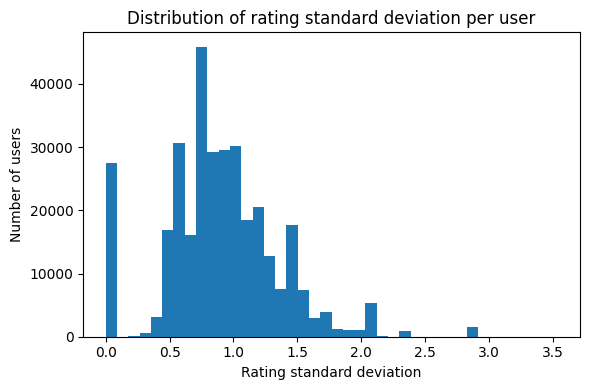

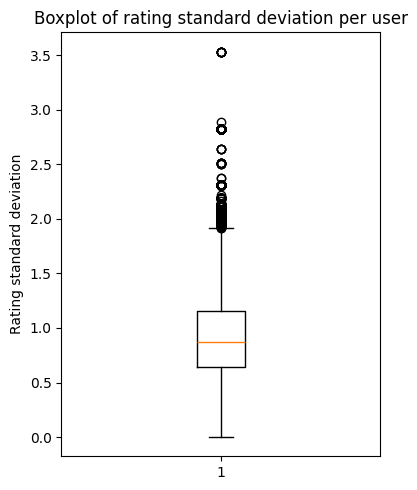

In [6]:
# 1.1.4 Distribution: standard deviation of ratings per user

data = user_statistics["std_rating"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=40)
plt.title("Distribution of rating standard deviation per user")
plt.xlabel("Rating standard deviation")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("Boxplot of rating standard deviation per user")
plt.ylabel("Rating standard deviation")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

Most users show **moderate rating variability**. Key observations:

- The bulk of the distribution sits in a low-to-moderate range, suggesting that the average user rates within a fairly narrow band.
- The **right tail** and boxplot outliers reveal a smaller group with highly volatile behavior, possibly reflecting eclectic taste or sparsity effects (few ratings leading to unstable statistics).
- `std_rating` complements `avg_rating` by capturing a different dimension: not just how positively a user rates, but how **consistently** they do so.

We inspect `activity_days`, which measures the time span between a user's first and last recorded rating. Like interaction counts, we expect a **heavy-tailed distribution**, so we compare linear and log-scale views and use a boxplot to highlight the most persistent users.

Mean: 275.43724585633373
Median: 102.0


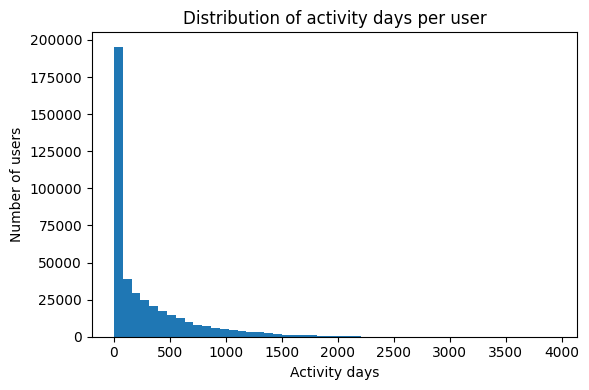

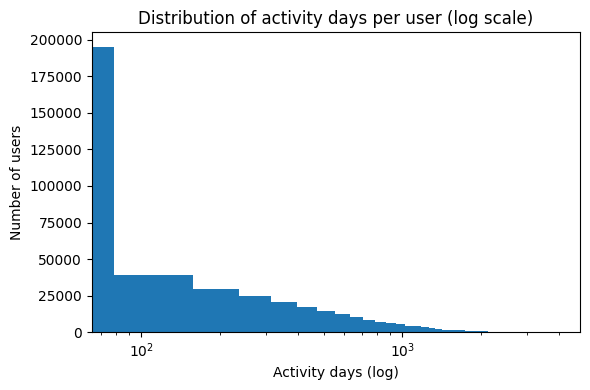

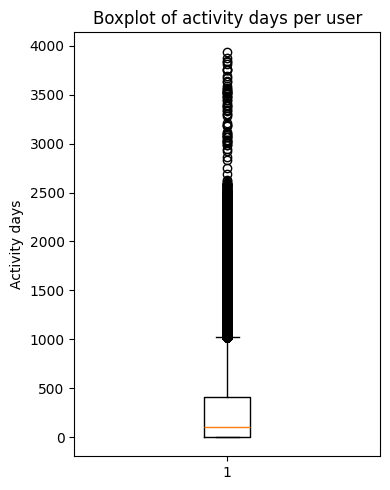

In [7]:
# 1.1.5 Distribution: activity (days) per user

data = user_statistics["activity_days"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.title("Distribution of activity days per user")
plt.xlabel("Activity days")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.xscale("log")
plt.title("Distribution of activity days per user (log scale)")
plt.xlabel("Activity days (log)")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("Boxplot of activity days per user")
plt.ylabel("Activity days")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

User activity spans a **wide temporal range** with strong right-skew. Key observations:

- Most users are active for a **relatively short period**, while a smaller set remains engaged over much longer windows.
- The log-scale histogram and boxplot extremes confirm **substantial heterogeneity** in user persistence.
- This variability is behaviorally meaningful for clustering: short-lived users and long-term regulars may exhibit fundamentally different preference patterns.

To detect redundancy and guide feature selection for clustering, we compute a **Pearson correlation heatmap** across the main user-level variables. We expect activity-related features (`total_ratings`, `unique_movies`, `activity_days`) to be positively correlated, while rating behavior features (`avg_rating`, `std_rating`) should show weaker relationships with engagement volume.

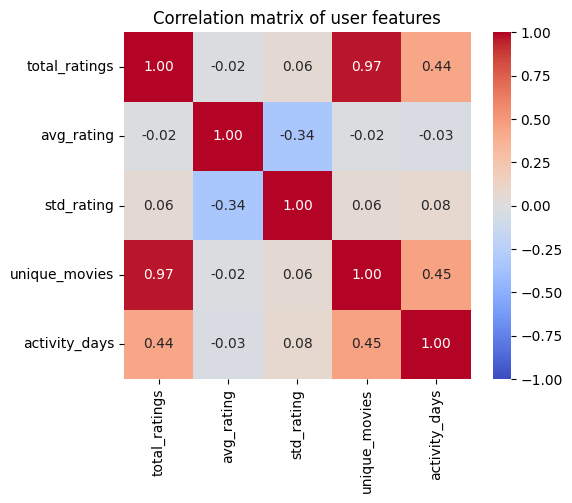

In [8]:
# 1.1.6 Correlation heatmap between user features (detect redundancy)

user_corr_cols = [
    "total_ratings",
    "avg_rating",
    "std_rating",
    "unique_movies",
    "activity_days"
]

user_corr_cols = [c for c in user_corr_cols if c in user_statistics.columns]

corr_users = user_statistics[user_corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_users,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation matrix of user features")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

The heatmap confirms a clear redundancy structure. Key observations:

- **`total_ratings` and `unique_movies`** show a strong positive correlation, confirming that both measure the same engagement dimension from slightly different angles. Keeping both would give disproportionate weight to activity volume in clustering.
- **`avg_rating` and `std_rating`** correlate weakly with activity features, confirming that rating behavior and interaction volume capture **complementary** user traits.
- These findings directly motivate the feature choices in Section 2: `unique_movies` is excluded from the clustering feature set, and a new derived feature (`rating_consistency`) replaces the raw `min_rating` / `max_rating` extremes.

# **1.2 EDA - MOVIE STATISTICS**

This section characterizes the `movie_statistics` table across four item-level dimensions:

1. **Popularity** (`total_ratings`, `unique_users`), how widely a movie has been watched and rated.
2. **Perceived quality** (`avg_rating`), the average rating a movie receives from viewers.
3. **Rating disagreement** (`std_rating`), how much viewers differ in their evaluations.
4. **Popularity vs. quality relationship**, a scatter plot testing whether popular movies are rated higher.

Since movie popularity follows an extreme long-tail distribution, log-scaled visualizations are used throughout. The section closes with a **correlation heatmap** to identify redundant features.

We begin with a structural inspection of the `movie_statistics` table, printing its dimensions and displaying the first few rows. This confirms how many movies are covered and validates that the expected feature columns are present before plotting any distributions.

In [9]:
# 1.2.1 Quick overview (shape, head)

print("Movie statistics dataset shape:", movie_statistics.shape)
movie_statistics.head()


Movie statistics dataset shape: (16015, 11)


,movie_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_users,first_rating_date,last_rating_date,year_of_release,title
0,1,548.0,3.744526,1.073389,1.0,5.0,548.0,2003-07-12,2005-12-30,2003.0,Dinosaur Planet
1,2,146.0,3.547945,1.281606,1.0,5.0,146.0,2004-10-16,2005-12-20,2004.0,Isle of Man TT 2004 Review
2,3,2013.0,3.639841,0.978873,1.0,5.0,2013.0,2000-10-19,2005-12-30,1997.0,Character
3,4,142.0,2.739437,1.302913,1.0,5.0,142.0,2003-12-06,2005-12-27,1994.0,Paula Abdul's Get Up & Dance
4,5,1140.0,3.919298,1.292436,1.0,5.0,1140.0,2004-11-02,2005-12-29,2004.0,The Rise and Fall of ECW


**Interpretation of the results.**

The shape output shows the total number of movie profiles available for analysis. The column preview confirms the presence of the key item-level fields (`total_ratings`, `avg_rating`, `std_rating`, `unique_users`) with no immediate structural issues.

We analyze `total_ratings`, the primary measure of movie popularity. Because a small number of blockbuster titles attract the vast majority of ratings while most movies remain niche or obscure, we expect an **extreme long-tail distribution**. We use linear and log-scale histograms and a boxplot to characterize this structure.

Mean: 260.04416694051923
Median: 1.0


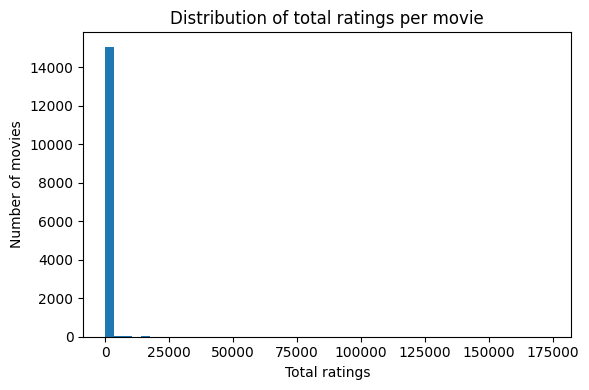

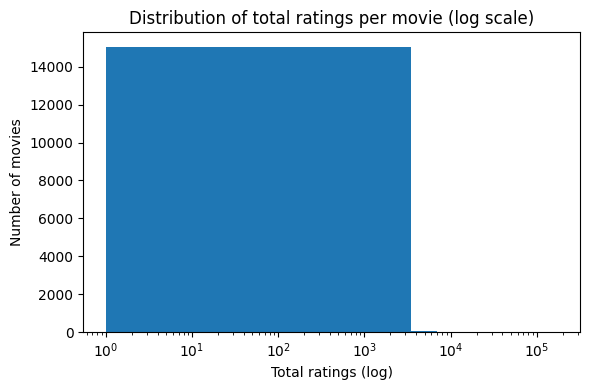

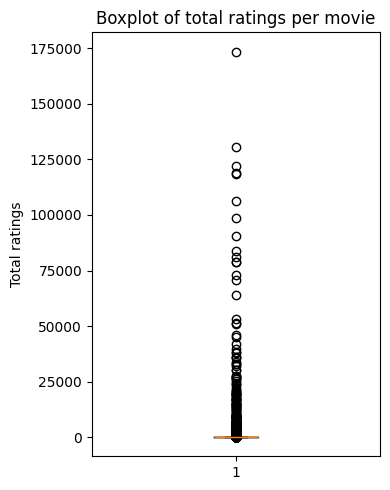

In [10]:
# 1.2.2 Distribution: total number of ratings per movie

data = movie_statistics["total_ratings"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.title("Distribution of total ratings per movie")
plt.xlabel("Total ratings")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.xscale("log")
plt.title("Distribution of total ratings per movie (log scale)")
plt.xlabel("Total ratings (log)")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("Boxplot of total ratings per movie")
plt.ylabel("Total ratings")
plt.tight_layout()
plt.show()


**Interpretation of the results.**

Movie popularity is **extremely long-tailed**. Key observations:

- The **mean is far above the median**, reflecting the outsized influence of a handful of blockbuster-level films.
- The **log-scale histogram** makes the full extent of the tail visible, many movies have only a handful of ratings.
- The **boxplot** highlights a small number of extreme outliers representing the most widely watched titles.

This distribution motivates the use of log-transformed popularity features and the **Bayesian average rating** introduced in Section 2, which prevents niche movies from appearing artificially high-quality based on small sample sizes.

We examine `avg_rating`, which captures perceived quality at the item level. Compared to popularity, we expect a more **compact distribution**, since most movies receive ratings across a moderate range. Extreme average ratings at the tails are typically associated with movies that have very few reviewers.

Mean: 2.9998512158938007
Median: 3.0


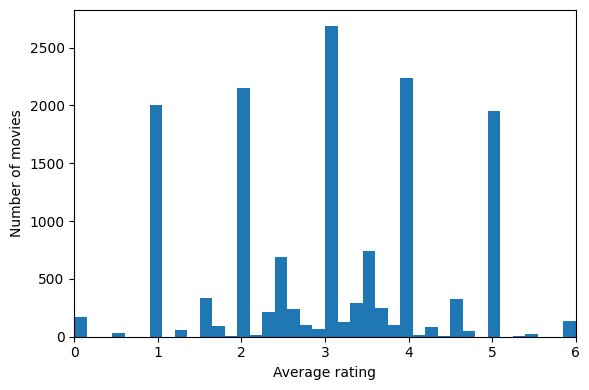

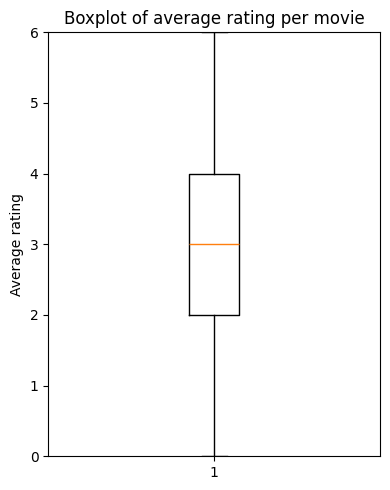

In [11]:
# 1.2.3 Distribution: average rating per movie

data = movie_statistics["avg_rating"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=40, range=(0, 6))
plt.xlabel("Average rating")
plt.ylabel("Number of movies")
plt.xlim(0, 6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("Boxplot of average rating per movie")
plt.ylabel("Average rating")
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

**Interpretation of the results.**

Average movie ratings are **concentrated around mid values**, with a neutral-to-slightly-positive overall evaluation pattern. Key observations:

- The distribution is **compact** relative to popularity metrics.
- The boxplot confirms meaningful variation across items, with some movies rated significantly above or below average.
- Extreme averages at the tails are typically explained by **very small sample sizes**, making these estimates unreliable. This directly motivates the use of **Bayesian-adjusted ratings** in Section 2.

We analyze `std_rating`, which measures how much viewers disagree when evaluating a movie. A low standard deviation indicates **broad consensus**, while a high value identifies **polarizing titles** that generate strongly divided opinions. This feature adds a controversy dimension to the movie representation that is independent of average quality.

Mean: 1.2579234787413824
Median: 1.2216989953222461


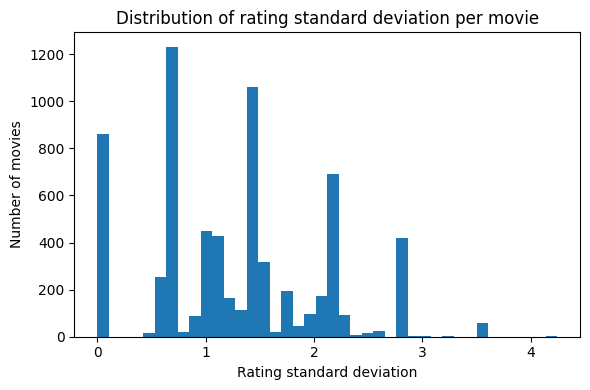

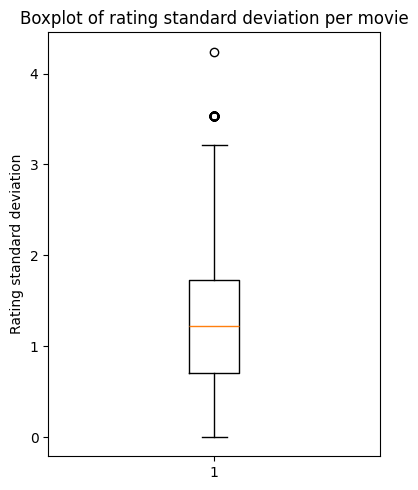

In [12]:
# 1.2.4 Distribution: standard deviation of ratings per movie

data = movie_statistics["std_rating"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=40)
plt.title("Distribution of rating standard deviation per movie")
plt.xlabel("Rating standard deviation")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("Boxplot of rating standard deviation per movie")
plt.ylabel("Rating standard deviation")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

Most movies show **moderate rating dispersion**, indicating some viewer disagreement but no extreme volatility. Key observations:

- The bulk of the distribution sits in a low-to-moderate range, reflecting broadly consistent evaluations for most titles.
- The **right tail** and boxplot outliers highlight a smaller subset of highly polarizing films.
- `std_rating` captures a dimension, **whether a film's reception is universal or divisive**, that is not conveyed by either `avg_rating` or `total_ratings` alone.

We inspect `unique_users`, which measures how many distinct viewers have rated a movie. This captures **audience breadth** as opposed to raw interaction volume (`total_ratings`). Since the two metrics should be strongly correlated, we expect the same long-tail shape observed for `total_ratings`.

Mean: 251.86434439697666
Median: 1.0


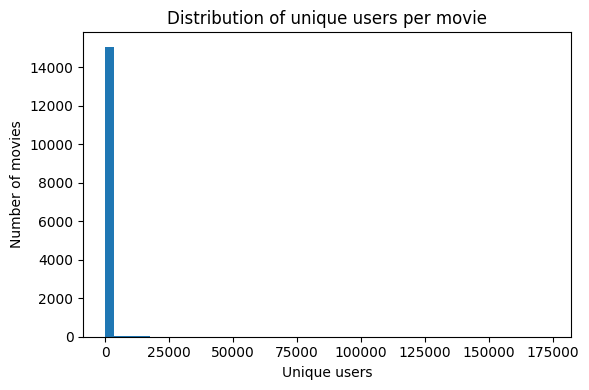

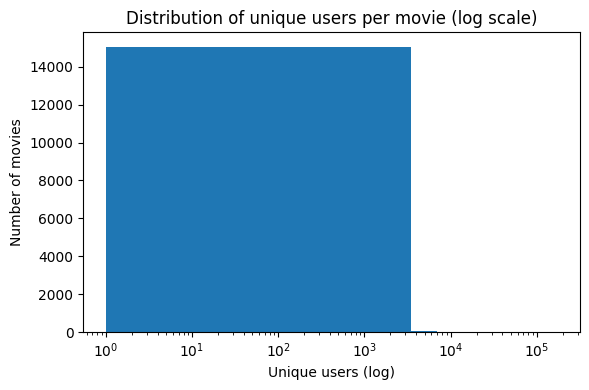

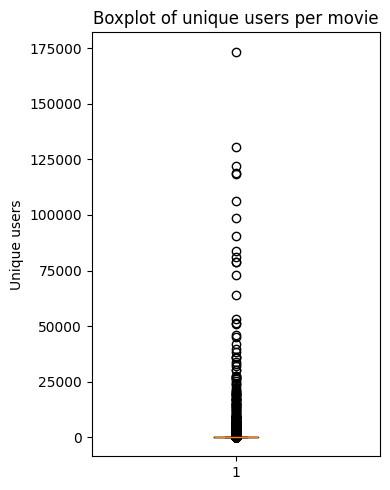

In [13]:
# 1.2.5 Distribution: unique users per movie

data = movie_statistics["unique_users"].dropna()

print("Mean:", data.mean())
print("Median:", data.median())

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.title("Distribution of unique users per movie")
plt.xlabel("Unique users")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(data, bins=50)
plt.xscale("log")
plt.title("Distribution of unique users per movie (log scale)")
plt.xlabel("Unique users (log)")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,5))
plt.boxplot(data, vert=True)
plt.title("Boxplot of unique users per movie")
plt.ylabel("Unique users")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

The distribution of `unique_users` is **highly right-skewed** and closely mirrors the shape of `total_ratings`. Key observations:

- The near-identical distribution shapes suggest **strong redundancy** between the two popularity metrics.
- This is confirmed quantitatively in the correlation heatmap (Section 1.2.7) and directly justifies excluding `unique_users` from the movie clustering feature set in Section 2.

We compare **popularity** (`total_ratings`) against **perceived quality** (`avg_rating`) in a scatter plot, using a log scale on the x-axis to handle the wide range of popularity values. This test checks whether widely watched movies are consistently rated higher, or whether popularity and quality behave as largely independent signals.

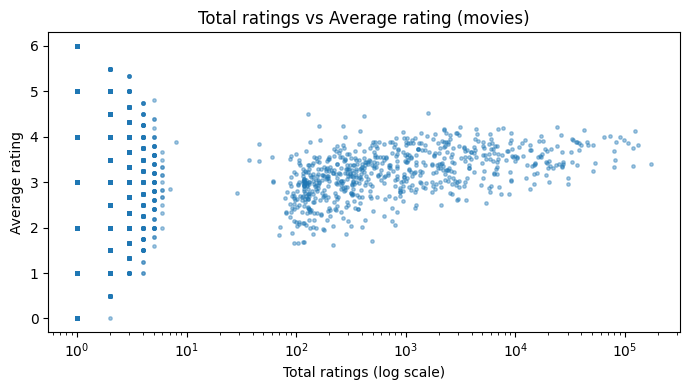

In [14]:
# 1.2.6 Scatter: popularity vs quality (log scale)

if {"total_ratings", "avg_rating"}.issubset(movie_statistics.columns):
    df = movie_statistics[["total_ratings", "avg_rating"]].dropna()

    plt.figure(figsize=(7,4))
    plt.scatter(df["total_ratings"], df["avg_rating"], s=6, alpha=0.4)
    plt.xscale("log")
    plt.title("Total ratings vs Average rating (movies)")
    plt.xlabel("Total ratings (log scale)")
    plt.ylabel("Average rating")
    plt.tight_layout()
    plt.show()

**Interpretation of the results.**

The scatter plot reveals **no strong linear relationship** between popularity and average rating. Key observations:

- Highly rated movies can be either niche or widely watched, confirming that quality and popularity are **largely independent dimensions**.
- Movies with **very few ratings** show a much wider spread in average values, reflecting statistical noise from small samples.
- Frequently rated movies tend to cluster within a **narrower quality band**, as their averages are stabilized by larger sample sizes.

This independence supports keeping both `total_ratings` and `bayesian_avg_rating` as separate features in the movie clustering pipeline.

We compute a **Pearson correlation heatmap** for the main movie-level features to quantify redundancy. We specifically expect `total_ratings` and `unique_users` to show a near-perfect positive correlation, since both measure popularity from slightly different angles.

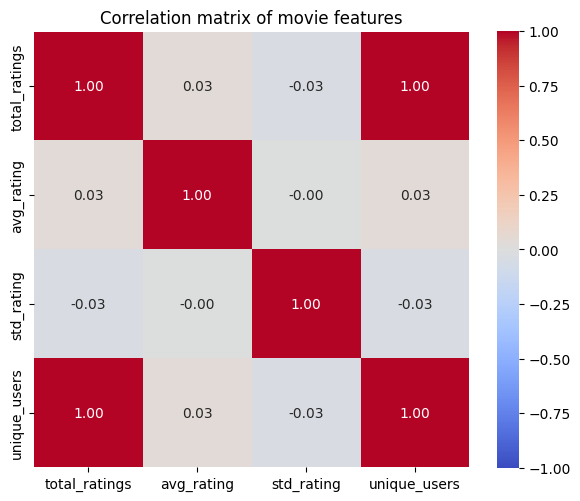

In [15]:
# 1.2.7 Movie features – Correlation heatmap

movie_corr_cols = [
    "total_ratings",
    "avg_rating",
    "std_rating",
    "unique_users"
]

movie_corr_cols = [c for c in movie_corr_cols if c in movie_statistics.columns]

corr_movies = movie_statistics[movie_corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_movies,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation matrix of movie features")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

The heatmap confirms a clear redundancy structure among movie features. Key observations:

- **`total_ratings` and `unique_users`** show a near-perfect positive correlation, confirming they capture essentially the same popularity signal. Keeping both in clustering would overweight this dimension without adding new information.
- **`avg_rating` and `std_rating`** correlate weakly with the popularity features, confirming that quality and viewer disagreement are largely independent of how widely a movie is watched.

These findings motivate the feature choices in Section 2: `unique_users` is excluded from the clustering feature set, and raw `avg_rating` is replaced by a Bayesian-adjusted version that corrects for sample-size effects.

# **2. PREPROCESSING**

This section cleans and prepares all four core datasets for downstream analysis. The pipeline follows five main steps:

1. **`viewer_ratings` cleaning**, removing invalid dates, missing keys, out-of-range ratings, and duplicate rows.
2. **`movies` cleaning**, enforcing the primary key, removing duplicates, and imputing missing release years.
3. **`movie_statistics` cleaning**, numeric conversion, median imputation, and derivation of `bayesian_avg_rating` and `rating_range`.
4. **`user_statistics` cleaning**, deduplication, activity reconstruction from timestamps, numeric conversion, imputation, and derivation of `rating_consistency`.
5. **Feature scaling**, standardizing user and movie feature matrices so all variables contribute comparably to clustering distance metrics.

**Median imputation** is used throughout to fill missing numeric values, as it preserves dataset coverage without being distorted by extreme outliers. A final referential integrity check confirms that all cleaned tables can be safely joined before clustering begins.

The EDA in Sections 1.1.6 and 1.2.7 revealed strong redundancy between activity and popularity variables: `total_ratings` correlates near-perfectly with `unique_movies` for users and with `unique_users` for movies. Retaining both features in clustering would give disproportionate weight to engagement volume without adding new information.

For this reason, **`unique_movies`** is excluded from the user feature set and **`unique_users`** from the movie feature set. Two more informative derived features replace the raw `min_rating` / `max_rating` extremes:

- **`rating_consistency`** (users): the ratio `avg_rating / (std_rating + ε)`, capturing how strongly and consistently a user holds their preferences.
- **`bayesian_avg_rating`** (movies): a Bayesian-shrunk quality estimate that corrects for sample-size effects, preventing movies with very few ratings from appearing artificially high-quality.

We apply a sequence of quality checks to the raw `viewer_ratings` table: date parsing with `errors="coerce"`, removal of rows flagged as `anomalous_date`, filtering for missing keys (`movie_id`, `customer_id`), rating-range validation (0–6 scale), and deduplication. Only rows that pass all checks are retained, producing a clean interaction log that can be safely joined to user and movie feature tables.

In [16]:
# 2.1 VIEWER_RATINGS

viewer_ratings_clean = viewer_ratings.copy()

print("Initial viewer_ratings shape:", viewer_ratings_clean.shape)
display(viewer_ratings_clean.head())
print("\nMissing values before cleaning (viewer_ratings):")
print(viewer_ratings_clean.isnull().sum())

# Convert `date` to datetime (invalid values -> NaT)
if "date" in viewer_ratings_clean.columns:
    viewer_ratings_clean["date"] = pd.to_datetime(
        viewer_ratings_clean["date"], errors="coerce"
    )

# Treat anomalous_date == "None" as missing (if present)
if "anomalous_date" in viewer_ratings_clean.columns:
    viewer_ratings_clean["anomalous_date"] = (
        viewer_ratings_clean["anomalous_date"].replace("None", np.nan)
    )

    viewer_ratings_clean = viewer_ratings_clean[
        ~(viewer_ratings_clean["anomalous_date"] == 1)
    ]

# Drop rows with missing keys (movie_id or customer_id)
viewer_ratings_clean = viewer_ratings_clean.dropna(subset=["movie_id", "customer_id"])

# Drop rows with missing ratings
viewer_ratings_clean = viewer_ratings_clean.dropna(subset=["rating"])

# Keep valid rating range for this dataset (0–6)
viewer_ratings_clean = viewer_ratings_clean[
    (viewer_ratings_clean["rating"] >= 0.0) &
    (viewer_ratings_clean["rating"] <= 6.0)
]

# Remove perfect duplicates
viewer_ratings_clean = viewer_ratings_clean.drop_duplicates()

# Reset index
viewer_ratings_clean = viewer_ratings_clean.reset_index(drop=True)

print("\n\nCleaned viewer_ratings shape:", viewer_ratings_clean.shape)
display(viewer_ratings_clean.head())
print("\nMissing values after cleaning (viewer_ratings):")
print(viewer_ratings_clean.isnull().sum())


Initial viewer_ratings shape: (4025000, 5)


,movie_id,customer_id,rating,date,anomalous_date
0,17,1481737,3.0,2005-10-09,NaN
1,9236,1448424,5.0,2005-11-15,NaN
2,4640,2308980,NaN,2005-08-06,NaN
3,9330,674346,3.0,2005-04-29,NaN
4,4570,1304045,4.0,2005-09-19,NaN



Missing values before cleaning (viewer_ratings):
movie_id                0
customer_id             0
rating             402500
date                    0
anomalous_date    4023791
dtype: int64


Cleaned viewer_ratings shape: (3621397, 5)


,movie_id,customer_id,rating,date,anomalous_date
0,17,1481737,3.0,2005-10-09,NaN
1,9236,1448424,5.0,2005-11-15,NaN
2,9330,674346,3.0,2005-04-29,NaN
3,4570,1304045,4.0,2005-09-19,NaN
4,9320,1036533,5.0,2004-08-05,NaN



Missing values after cleaning (viewer_ratings):
movie_id                0
customer_id             0
rating                  0
date                    0
anomalous_date    3621397
dtype: int64


In [17]:
# Confirm that no anomalous-date rows remain after filtering
viewer_ratings_clean["anomalous_date"].notna().sum()

np.int64(0)

**Interpretation of the results.**

The before/after shapes confirm that a small fraction of records were removed. Key observations:

- **Anomalous-date rows** are fully excluded: the confirmation cell shows zero remaining rows with a non-null `anomalous_date`.
- **Missing key and out-of-range rows** were dropped to preserve referential integrity and score validity.
- The resulting `viewer_ratings_clean` table is consistent across all key columns and ready to be joined with user and movie cluster assignments.

We clean the `movies` table by enforcing the primary key (`movie_id`), removing duplicate entries, and ensuring that `title` and `year_of_release` are present. Missing values in `year_of_release` are filled with the **column median**, a simple, outlier-resistant strategy that avoids losing movies during downstream joins.

In [18]:
# 2.2 MOVIES

movies_clean = movies.copy()

print("Initial movies shape:", movies_clean.shape)
display(movies_clean.head())
print("\nMissing values before cleaning (movies):")
print(movies_clean.isnull().sum())

# Drop rows with missing movie_id (primary key)
movies_clean = movies_clean.dropna(subset=["movie_id"])

# Remove duplicate movie_id rows (keep first occurrence)
movies_clean = movies_clean.drop_duplicates(subset=["movie_id"], keep="first")

# Drop rows with missing title
if "title" in movies_clean.columns:
    movies_clean = movies_clean.dropna(subset=["title"])

# After cleaning release_year, force imputation to remove ALL NaN
movies_clean["year_of_release"] = movies_clean["year_of_release"].fillna(
    movies_clean["year_of_release"].median()
)

# Ensure no missing values remain
movies_clean = movies_clean.dropna(subset=["year_of_release", "title"])

print("\n\nCleaned movies shape:", movies_clean.shape)
display(movies_clean.head())
print("\nMissing values after cleaning (movies):")
print(movies_clean.isnull().sum())


Initial movies shape: (18008, 3)


,movie_id,year_of_release,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW



Missing values before cleaning (movies):
movie_id           0
year_of_release    7
title              0
dtype: int64


Cleaned movies shape: (18006, 3)


,movie_id,year_of_release,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW



Missing values after cleaning (movies):
movie_id           0
year_of_release    0
title              0
dtype: int64


**Interpretation of the results.**

After cleaning, each movie has a valid `movie_id`, a non-null `title`, and a `year_of_release`. The shape comparison shows how many duplicates or incomplete entries were removed. The resulting `movies_clean` table is the reference source for movie titles displayed in the recommendation output.

Before applying any transformations to `movie_statistics`, we inspect its shape and missing-value counts column by column. This step identifies which numeric fields are stored as strings (requiring type coercion) and which columns have significant gaps that will need imputation.

In [19]:
# 2.3.1 MOVIE_STATISTICS — Initial inspection

movie_statistics_clean = movie_statistics.copy()

print("Initial movie_statistics shape:", movie_statistics_clean.shape)
display(movie_statistics_clean.head())
print("\nMissing values before cleaning (movie_statistics):")
print(movie_statistics_clean.isnull().sum())


Initial movie_statistics shape: (16015, 11)


,movie_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_users,first_rating_date,last_rating_date,year_of_release,title
0,1,548.0,3.744526,1.073389,1.0,5.0,548.0,2003-07-12,2005-12-30,2003.0,Dinosaur Planet
1,2,146.0,3.547945,1.281606,1.0,5.0,146.0,2004-10-16,2005-12-20,2004.0,Isle of Man TT 2004 Review
2,3,2013.0,3.639841,0.978873,1.0,5.0,2013.0,2000-10-19,2005-12-30,1997.0,Character
3,4,142.0,2.739437,1.302913,1.0,5.0,142.0,2003-12-06,2005-12-27,1994.0,Paula Abdul's Get Up & Dance
4,5,1140.0,3.919298,1.292436,1.0,5.0,1140.0,2004-11-02,2005-12-29,2004.0,The Rise and Fall of ECW



Missing values before cleaning (movie_statistics):
movie_id                0
total_ratings         800
avg_rating            800
std_rating           9168
min_rating            800
max_rating            800
unique_users          800
first_rating_date       0
last_rating_date        0
year_of_release      4511
title                4507
dtype: int64


**Interpretation of the results.**

The missing-value summary pinpoints which columns require `pd.to_numeric()` conversion with `errors="coerce"` and which will need median imputation to prevent `NaN` values from propagating into the scaled feature matrix used for clustering.

We clean `movie_statistics` by enforcing the primary key (`movie_id`), removing duplicates, converting all numeric columns with coercion, and applying **median imputation** for any remaining gaps. Two additional features are then derived:

- **`bayesian_avg_rating`**: computed as `(v × R + C × m) / (v + C)`, where `v` = rating count, `R` = raw average, `C` = median count (prior), and `m` = global mean. This shrinks extreme averages toward the global mean for movies with few ratings, preventing cold-start overestimation.
- **`rating_range`**: `max_rating − min_rating`, clipped to zero. This captures how **polarizing** a movie is more meaningfully than keeping raw `min_rating` and `max_rating` as separate features.

In [20]:
# 2.3.2 MOVIE_STATISTICS — Cleaning + numeric conversion + missing checks

# Drop rows with missing movie_id
movie_statistics_clean = movie_statistics_clean.dropna(subset=["movie_id"])

# Remove duplicated movie_id
movie_statistics_clean = movie_statistics_clean.drop_duplicates(subset=["movie_id"], keep="first")

# Numeric columns for movie-level stats
movie_stat_cols = [
    "total_ratings",
    "avg_rating",
    "std_rating",
    "min_rating",
    "max_rating",
    "unique_users",
]
movie_stat_cols = [c for c in movie_stat_cols if c in movie_statistics_clean.columns]

print("\nNumeric columns used for movie_statistics cleaning:", movie_stat_cols)

# Convert to numeric
for col in movie_stat_cols:
    movie_statistics_clean[col] = pd.to_numeric(
        movie_statistics_clean[col], errors="coerce"
    )

# Median imputation
for col in movie_stat_cols:
    median_val = movie_statistics_clean[col].median()
    movie_statistics_clean[col] = movie_statistics_clean[col].fillna(median_val)

# Bayesian average rating: shrinks raw avg_rating toward the global mean for movies
# with few ratings, preventing cold-start overestimation of quality.
# Formula: (v*R + C*m) / (v+C), where v=count, R=raw_avg, C=prior_count, m=global_mean
if {"total_ratings", "avg_rating"}.issubset(movie_statistics_clean.columns):
    C_prior = movie_statistics_clean["total_ratings"].median()
    global_movie_avg = movie_statistics_clean["avg_rating"].mean()
    v = movie_statistics_clean["total_ratings"]
    R = movie_statistics_clean["avg_rating"]
    movie_statistics_clean["bayesian_avg_rating"] = (
        (v * R + C_prior * global_movie_avg) / (v + C_prior)
    )

# Rating range: max − min is a spread/polarization signal, more meaningful than
# keeping raw min and max as separate features.
if {"min_rating", "max_rating"}.issubset(movie_statistics_clean.columns):
    movie_statistics_clean["rating_range"] = (
        movie_statistics_clean["max_rating"] - movie_statistics_clean["min_rating"]
    ).clip(lower=0)

movie_statistics_clean = movie_statistics_clean.reset_index(drop=True)

print("\nCleaned movie_statistics shape:", movie_statistics_clean.shape)
display(movie_statistics_clean.head())
print("\nMissing values after cleaning (movie_statistics):")
print(movie_statistics_clean[movie_stat_cols].isnull().sum())


Numeric columns used for movie_statistics cleaning: ['total_ratings', 'avg_rating', 'std_rating', 'min_rating', 'max_rating', 'unique_users']

Cleaned movie_statistics shape: (16013, 13)


,movie_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_users,first_rating_date,last_rating_date,year_of_release,title,bayesian_avg_rating,rating_range
0,1,548.0,3.744526,1.073389,1.0,5.0,548.0,2003-07-12,2005-12-30,2003.0,Dinosaur Planet,3.743169,4.0
1,2,146.0,3.547945,1.281606,1.0,5.0,146.0,2004-10-16,2005-12-20,2004.0,Isle of Man TT 2004 Review,3.544216,4.0
2,3,2013.0,3.639841,0.978873,1.0,5.0,2013.0,2000-10-19,2005-12-30,1997.0,Character,3.639523,4.0
3,4,142.0,2.739437,1.302913,1.0,5.0,142.0,2003-12-06,2005-12-27,1994.0,Paula Abdul's Get Up & Dance,2.741257,4.0
4,5,1140.0,3.919298,1.292436,1.0,5.0,1140.0,2004-11-02,2005-12-29,2004.0,The Rise and Fall of ECW,3.918492,4.0



Missing values after cleaning (movie_statistics):
total_ratings    0
avg_rating       0
std_rating       0
min_rating       0
max_rating       0
unique_users     0
dtype: int64


**Interpretation of the results.**

The cleaned table contains no missing values in any numeric column, confirming that type conversion and median imputation completed successfully. Two new columns, `bayesian_avg_rating` and `rating_range`, are now available and will replace the raw `avg_rating`, `min_rating`, and `max_rating` fields in the movie clustering feature set.

We apply the same cleaning sequence to `user_statistics`: deduplication, `activity_days` reconstruction from timestamps, numeric conversion, and median imputation. We then derive **`rating_consistency`**, defined as `avg_rating / (std_rating + ε)`. This ratio captures how strongly and uniformly a user rates items, a high value indicates consistent positive evaluations, while a low value suggests variable or mixed behavior. It replaces the raw `min_rating` and `max_rating` extremes, which carry very little discriminative information at the user level.

**Note on `activity_days` reconstruction.** The original `activity_days` column contains missing values for a subset of users. Rather than dropping these rows, we reconstruct the feature directly from `first_rating_days` and `last_rating_days` by converting both to datetime and computing the elapsed days. This recovers the missing values for all users whose timestamps are available, preserving additional records without introducing new assumptions.

In [21]:
# 2.4 USER_STATISTICS

user_statistics_clean = user_statistics.copy()

print("Initial user_statistics shape:", user_statistics_clean.shape)
display(user_statistics_clean.head())
print("\nMissing values before cleaning (user_statistics):")
print(user_statistics_clean.isnull().sum())

# Remove duplicate user IDs
user_statistics_clean = user_statistics_clean.drop_duplicates(
    subset=["customer_id"], keep="first"
)

# Reconstruct activity_days from first/last rating timestamps
if {"first_rating_days", "last_rating_days"}.issubset(user_statistics_clean.columns):
    user_statistics_clean["first_rating_days"] = pd.to_datetime(
        user_statistics_clean["first_rating_days"], errors="coerce"
    )
    user_statistics_clean["last_rating_days"] = pd.to_datetime(
        user_statistics_clean["last_rating_days"], errors="coerce"
    )

    user_statistics_clean["activity_days"] = (
        user_statistics_clean["last_rating_days"] -
        user_statistics_clean["first_rating_days"]
    ).dt.days

    # Remove inconsistent spans (negative values)
    user_statistics_clean.loc[
        user_statistics_clean["activity_days"] < 0, "activity_days"
    ] = np.nan
else:
    if "activity_days" in user_statistics_clean.columns:
        user_statistics_clean.loc[
            user_statistics_clean["activity_days"] < 0, "activity_days"
        ] = np.nan

# Convert numeric columns (do not include activity_days here)
numeric_cols = [
    "total_ratings",
    "avg_rating",
    "std_rating",
    "min_rating",
    "max_rating",
    "unique_movies"
]
numeric_cols = [c for c in numeric_cols if c in user_statistics_clean.columns]

for col in numeric_cols:
    user_statistics_clean[col] = pd.to_numeric(
        user_statistics_clean[col], errors="coerce"
    )

# Ensure activity_days is numeric (it already is if reconstructed)
if "activity_days" in user_statistics_clean.columns:
    user_statistics_clean["activity_days"] = pd.to_numeric(
        user_statistics_clean["activity_days"], errors="coerce"
    )

# Median imputation
impute_cols = numeric_cols + (["activity_days"] if "activity_days" in user_statistics_clean.columns else [])
for col in impute_cols:
    median_val = user_statistics_clean[col].median()
    user_statistics_clean[col] = user_statistics_clean[col].fillna(median_val)

# Rating consistency: avg/std ratio captures how strongly and consistently a user
# holds their preferences. High = strong positive sentiment with low variance.
# More informative for clustering than raw min/max single-point extremes.
if {"avg_rating", "std_rating"}.issubset(user_statistics_clean.columns):
    user_statistics_clean["rating_consistency"] = (
        user_statistics_clean["avg_rating"] / (user_statistics_clean["std_rating"] + 1e-8)
    )

user_statistics_clean = user_statistics_clean.reset_index(drop=True)

print("\n\nCleaned user_statistics shape:", user_statistics_clean.shape)
display(user_statistics_clean.head())

print("\nMissing values after cleaning (user_statistics):")
print(user_statistics_clean[impute_cols].isnull().sum())

Initial user_statistics shape: (438780, 10)


,customer_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_movies,first_rating_date,last_rating_date,activity_days
0,1965326,8.0,3.250000,0.886405,2.0,5.0,8.0,2004-08-11,2005-06-06,299.0
1,506434,1.0,4.000000,NaN,4.0,4.0,1.0,2005-08-02,2005-08-02,0.0
2,1365167,3.0,4.666667,0.577350,4.0,5.0,3.0,2004-11-16,2005-01-19,64.0
3,396632,2.0,NaN,0.000000,4.0,4.0,2.0,2004-07-07,2004-07-07,0.0
4,260614,3.0,4.333333,0.577350,4.0,5.0,3.0,2004-03-02,2004-10-13,NaN



Missing values before cleaning (user_statistics):
customer_id               0
total_ratings         21939
avg_rating            21939
std_rating           106252
min_rating            21939
max_rating            21939
unique_movies         21939
first_rating_date         0
last_rating_date          0
activity_days         21939
dtype: int64


Cleaned user_statistics shape: (438780, 11)


,customer_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_movies,first_rating_date,last_rating_date,activity_days,rating_consistency
0,1965326,8.0,3.250000,0.886405,2.0,5.0,8.0,2004-08-11,2005-06-06,299.0,3.666494e+00
1,506434,1.0,4.000000,0.867759,4.0,4.0,1.0,2005-08-02,2005-08-02,0.0,4.609572e+00
2,1365167,3.0,4.666667,0.577350,4.0,5.0,3.0,2004-11-16,2005-01-19,64.0,8.082904e+00
3,396632,2.0,3.687500,0.000000,4.0,4.0,2.0,2004-07-07,2004-07-07,0.0,3.687500e+08
4,260614,3.0,4.333333,0.577350,4.0,5.0,3.0,2004-03-02,2004-10-13,102.0,7.505553e+00



Missing values after cleaning (user_statistics):
total_ratings    0
avg_rating       0
std_rating       0
min_rating       0
max_rating       0
unique_movies    0
activity_days    0
dtype: int64


**Interpretation of the results.**

The cleaned `user_statistics_clean` table has no missing values in any selected numeric column, and the new `rating_consistency` feature is populated for all users. The shape output shows the number of valid user profiles retained after deduplication and cleaning, ready for feature selection and scaling.

We define the final feature set for user-level clustering. The selection captures **five distinct behavioral dimensions** with minimal redundancy:

- **`total_ratings`**: overall engagement volume.
- **`avg_rating`**: typical rating level, summarizing positive or negative tendencies.
- **`std_rating`**: rating variability, distinguishing consistent from erratic raters.
- **`rating_consistency`** (derived): `avg_rating / std_rating`, capturing the strength and stability of a user's preferences. Replaces the uninformative raw `min_rating` / `max_rating` extremes.
- **`activity_days`**: temporal engagement span.

**`unique_movies`** is excluded because it is near-perfectly correlated with `total_ratings` (Section 1.1.6) and would redundantly inflate the weight of engagement volume in the distance metric.

In [22]:
# 2.5 User-level features & scaling

# 2.5.1 Select numerical features for user-level clustering
# Removed: min_rating, max_rating (single-point extremes, low discriminative power)
#          unique_movies (near-perfect correlation with total_ratings — Section 1.1.6)
# Added:   rating_consistency (avg/std ratio: captures preference strength + stability)
user_feature_cols = [
    "total_ratings",
    "avg_rating",
    "std_rating",
    "rating_consistency",
    "activity_days",
]

# Keep only columns that actually exist
user_feature_cols = [c for c in user_feature_cols if c in user_statistics_clean.columns]

user_features = user_statistics_clean[["customer_id"] + user_feature_cols].copy()

print("Initial user_features shape:", user_features.shape)
display(user_features.head())

Initial user_features shape: (438780, 6)


,customer_id,total_ratings,avg_rating,std_rating,rating_consistency,activity_days
0,1965326,8.0,3.250000,0.886405,3.666494e+00,299.0
1,506434,1.0,4.000000,0.867759,4.609572e+00,0.0
2,1365167,3.0,4.666667,0.577350,8.082904e+00,64.0
3,396632,2.0,3.687500,0.000000,3.687500e+08,0.0
4,260614,3.0,4.333333,0.577350,7.505553e+00,102.0


**Interpretation of the results.**

The `user_features` table has one row per user and five columns covering engagement volume, rating behavior, and temporal persistence. This compact, non-redundant representation forms the input to the user clustering pipeline.

To reduce the leverage of extreme power users on centroid positions, we apply a **conservative outlier filter** by removing users whose `total_ratings` exceeds the 99th percentile. This trims a very small fraction of the dataset while meaningfully improving cluster stability, since a handful of hyper-active users can otherwise pull centroids far from the bulk of the distribution.

In [23]:
# 2.5.2 Remove extreme outliers in total_ratings (user-level)

if "total_ratings" in user_feature_cols:
    upper_thr_users = user_features["total_ratings"].quantile(0.99)
    user_features_clean = user_features[user_features["total_ratings"] <= upper_thr_users].reset_index(drop=True)
else:
    user_features_clean = user_features.copy().reset_index(drop=True)

print("Shape after removing extreme outliers (user_features_clean):", user_features_clean.shape)

Shape after removing extreme outliers (user_features_clean): (434429, 6)


**Interpretation of the results.**

`user_features_clean` retains the vast majority of users. The small row-count reduction (the top 1% by `total_ratings`) ensures that centroid positions are not disproportionately influenced by a few extreme data points.

We apply `StandardScaler` to the user feature matrix, transforming each column to zero mean and unit variance. Without this step, high-magnitude features like `total_ratings` (reaching thousands) would dominate Euclidean distances over features on smaller scales like `avg_rating` (0–6), making the clustering reflect scale differences rather than behavioral structure.

In [24]:
# 2.5.3 Standardize numerical features (user-level)

user_scaler = StandardScaler()
X_users = user_features_clean[user_feature_cols].values
X_users_scaled = user_scaler.fit_transform(X_users)

print("Scaled user feature matrix shape:", X_users_scaled.shape)

Scaled user feature matrix shape: (434429, 5)


**Interpretation of the results.**

`X_users_scaled` is a 2D numpy array with one row per user and one column per feature, all on a comparable scale. This matrix is the direct input to K-Means, MiniBatch K-Means, and BIRCH in Section 4.

We define the final feature set for movie-level clustering. The selection captures **four distinct item-level dimensions**:

- **`total_ratings`**: popularity and audience reach.
- **`bayesian_avg_rating`** (derived): a Bayesian-shrunk quality estimate, more reliable than raw `avg_rating` for movies with few ratings.
- **`std_rating`**: rating disagreement and viewer polarization.
- **`rating_range`** (derived): `max − min` spread, capturing whether a movie's reception is narrow (consensus) or wide (controversy).

**`unique_users`** is excluded due to near-perfect correlation with `total_ratings` (Section 1.2.7), and raw `min_rating` / `max_rating` are replaced by `rating_range`, which encodes the same spread information in a single, more meaningful feature.

In [25]:
# 2.6 Movie-level features & scaling
# 2.6.1 Select numerical features for movie-level clustering
# Removed: min_rating, max_rating (single-point extremes, replaced by rating_range)
#          unique_users (near-perfect correlation with total_ratings — Section 1.2.7)
#          avg_rating (replaced by bayesian_avg_rating, which corrects for sample size)
# Added:   bayesian_avg_rating (Bayesian shrinkage toward global mean for sparse movies)
#          rating_range (max − min: captures controversy/polarization)
movie_feature_cols = [
    "total_ratings",
    "bayesian_avg_rating",
    "std_rating",
    "rating_range",
]
movie_feature_cols = [c for c in movie_feature_cols if c in movie_statistics_clean.columns]

movie_features = movie_statistics_clean[["movie_id"] + movie_feature_cols].copy()

print("Initial movie_features shape:", movie_features.shape)
display(movie_features.head())

Initial movie_features shape: (16013, 5)


,movie_id,total_ratings,bayesian_avg_rating,std_rating,rating_range
0,1,548.0,3.743169,1.073389,4.0
1,2,146.0,3.544216,1.281606,4.0
2,3,2013.0,3.639523,0.978873,4.0
3,4,142.0,2.741257,1.302913,4.0
4,5,1140.0,3.918492,1.292436,4.0


**Interpretation of the results.**

The `movie_features` table has one row per movie and four columns covering popularity, quality, dispersion, and polarization. This feature set removes the redundant and noisy variables identified in the EDA and introduces the Bayesian-corrected quality estimate that improves both clustering quality and downstream recommendation scoring.

We apply `StandardScaler` to the movie feature matrix for the same reason as with users: clustering distance metrics must not be dominated by high-magnitude variables such as `total_ratings`. Standardization places all four features on a comparable scale before computing distances.

In [26]:
# 2.6.2 Standardize numerical features (movie-level)

movie_scaler = StandardScaler()
X_movies = movie_features[movie_feature_cols].values
X_movies_scaled = movie_scaler.fit_transform(X_movies)

print("Scaled movie feature matrix shape:", X_movies_scaled.shape)

Scaled movie feature matrix shape: (16013, 4)


**Interpretation of the results.**

`X_movies_scaled` is a 2D numpy array with one row per movie and four standardized columns. This matrix is the direct input to K-Means, MiniBatch K-Means, and BIRCH in Section 5.

Before clustering, we perform a **referential integrity check** to confirm that user IDs and movie IDs in `viewer_ratings_clean` can be matched to corresponding rows in the user and movie feature tables. Any unmatched IDs would create orphan interactions that cannot be assigned a cluster, causing silent data loss during the affinity computation in Section 6.

In [27]:
# Check what fraction of cleaned ratings can be linked to the user and movie feature tables
user_coverage = viewer_ratings_clean["customer_id"].isin(user_features_clean["customer_id"]).mean()
movie_coverage = viewer_ratings_clean["movie_id"].isin(movie_features["movie_id"]).mean()

print("User coverage in ratings vs user_features_clean:", user_coverage)
print("Movie coverage in ratings vs movie_features:", movie_coverage)

User coverage in ratings vs user_features_clean: 0.9143954667218204
Movie coverage in ratings vs movie_features: 1.0


**Interpretation of the results.**

The coverage check confirms the datasets are consistently linked. Key observations:

- **Movie coverage is complete** (1.0): every `movie_id` in `viewer_ratings_clean` has a matching entry in `movie_features`, so no interaction is lost when joining on `movie_id`.
- **User coverage is slightly below 1.0**: a small fraction of interactions belong to users removed by the 99th-percentile outlier filter in Section 2.5.2. This is expected and only affects the most extreme power users.

The datasets are ready to be merged for clustering and affinity analysis.

# **3. HELPER FUNCTIONS: CENTROID SILHOUETTE & WCSS**


This section defines two utility functions used consistently throughout Sections 4 and 5 to evaluate clustering quality:

1. **`centroid_silhouette`**, a scalable approximation of the classic Silhouette score. Instead of computing all pairwise point distances (O(n²)), it uses distances to cluster centroids, making it practical for datasets with hundreds of thousands of rows.
2. **`compute_wcss`**, a generic Within-Cluster Sum of Squares function that works with any clustering assignment, enabling consistent elbow-method diagnostics across K-Means, MiniBatch K-Means, and BIRCH.

Together, these metrics provide **complementary signals** for model selection: WCSS measures within-cluster compactness, while the centroid-based Silhouette approximates between-cluster separation.

The standard Silhouette score requires O(n²) pairwise distance computations, which becomes prohibitive for datasets with hundreds of thousands of users. Our **centroid-based approximation** replaces point-to-point distances with distances to cluster centroids, reducing complexity to O(n × k) while preserving the core intuition.

The implementation uses **fully vectorized NumPy operations**: cluster membership indices are resolved with `np.searchsorted` (O(n log k)), and the nearest-other-centroid distance is found by setting each point's own-centroid entry to `inf` and taking a row-wise minimum, no Python-level loops anywhere.

In [28]:
# 3.1 Centroid-based Silhouette

def centroid_silhouette(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    unique_labels = np.unique(labels)
    k = len(unique_labels)
    if k < 2:
        return np.nan

    # Vectorized cluster index: O(n log k) searchsorted instead of O(n*k) np.where loop
    sorter = np.argsort(unique_labels)
    cluster_index = sorter[np.searchsorted(unique_labels, labels, sorter=sorter)]

    # Compute centroids for each cluster
    centroids = np.array([
        X[labels == c].mean(axis=0)
        for c in unique_labels
    ])

    # Distance from each point to each centroid
    dist_matrix = np.sqrt(
        ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    )

    # a(i): distance to own cluster centroid
    a = dist_matrix[np.arange(len(X)), cluster_index]

    # b(i): smallest distance to any other centroid (vectorized, no Python loop)
    dist_others = dist_matrix.copy()
    dist_others[np.arange(len(X)), cluster_index] = np.inf
    b = dist_others.min(axis=1)

    # Silhouette for each point
    s = (b - a) / np.maximum(a, b)

    return float(np.mean(s))

**Interpretation of the function design.**

For each data point, the function computes two distances:

- **a(i)**: distance to its own cluster centroid, measuring cohesion.
- **b(i)**: distance to the nearest *other* centroid, measuring separation.

The per-point Silhouette is `(b − a) / max(a, b)`, and the function returns the **mean across all points**. Values near **1.0** indicate well-separated, compact clusters. Values near **0** indicate overlapping boundaries. Negative values indicate that many points are closer to a neighboring centroid than to their own.

We define `compute_wcss`, a generic function that computes the **Within-Cluster Sum of Squares** for any set of cluster labels and a feature matrix. Unlike `KMeans.inertia_` (available only for scikit-learn K-Means objects), this function is algorithm-agnostic, enabling a consistent elbow-method comparison across K-Means, MiniBatch K-Means, and BIRCH.

In [29]:
# 3.2 Compute WCSS given labels (generic, for K-Means / MiniBatch / BIRCH)

def compute_wcss(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    unique_labels = np.unique(labels)
    wcss = 0.0
    for c in unique_labels:
        cluster_points = X[labels == c]
        centroid = cluster_points.mean(axis=0)
        wcss += ((cluster_points - centroid) ** 2).sum()
    return float(wcss)


**Interpretation of the function design.**

`compute_wcss` iterates over each cluster, computes the centroid as the mean of all assigned points, and sums the squared Euclidean distances from each point to its centroid. The resulting scalar measures **total within-cluster variance**: lower values indicate more compact, homogeneous groups. When plotted against increasing values of k, the rate at which WCSS decreases reveals the **elbow point** where adding more clusters stops providing meaningful compactness gains.

# **4. USER CLUSTERING (K-Means, MiniBatch K-Means, BIRCH)**

This section segments users into behavioral groups using three centroid-based algorithms on the standardized user feature matrix. The workflow follows six main steps:

1. **k-range exploration**, K-Means, MiniBatch K-Means, and BIRCH are each evaluated across k ∈ {3, …, 9}, tracking WCSS and centroid-based Silhouette for every configuration.
2. **Elbow and Silhouette plots**, visual diagnostics are produced for all three algorithms to identify the compactness-separation trade-off.
3. **Global k selection**, a **consensus rule** picks the final k: if at least two models agree on the silhouette-optimal k, that value is used; otherwise the k maximizing the average Silhouette across all three models is adopted.
4. **Final model fit**, all three algorithms are re-trained with the chosen k and labels are stored.
5. **PCA visualization**, the feature space is projected into 2D to qualitatively inspect cluster separation.
6. **Model comparison**, a composite ranking score (combining Silhouette quality, cluster-size balance, and computation time) identifies the best algorithm for downstream use.

We define `k_values = list(range(3, 10))` as the shared candidate range used by all three algorithms. The range is intentionally kept small to prioritize **interpretability** (fewer clusters are easier to profile) while still providing enough options for meaningful elbow and Silhouette trends. A fixed range also ensures all evaluation curves are directly comparable across algorithms.

In [30]:
# 4.1 Range of k values to explore

k_values = list(range(3, 10))
print("k_values:", k_values)


k_values: [3, 4, 5, 6, 7, 8, 9]


**Interpretation of the results.**

The printed list confirms the seven candidate cluster counts. Using the same range for all three algorithms guarantees a fair, model-agnostic comparison in the steps that follow.

We fit **K-Means** with `k-means++` initialization and 10 restarts (`n_init=10`) for each candidate k, recording the model's inertia (equal to WCSS) and the centroid-based Silhouette score. Both metrics are plotted side by side: the **elbow curve** shows where WCSS gains diminish, and the **Silhouette curve** identifies the k that best separates clusters.

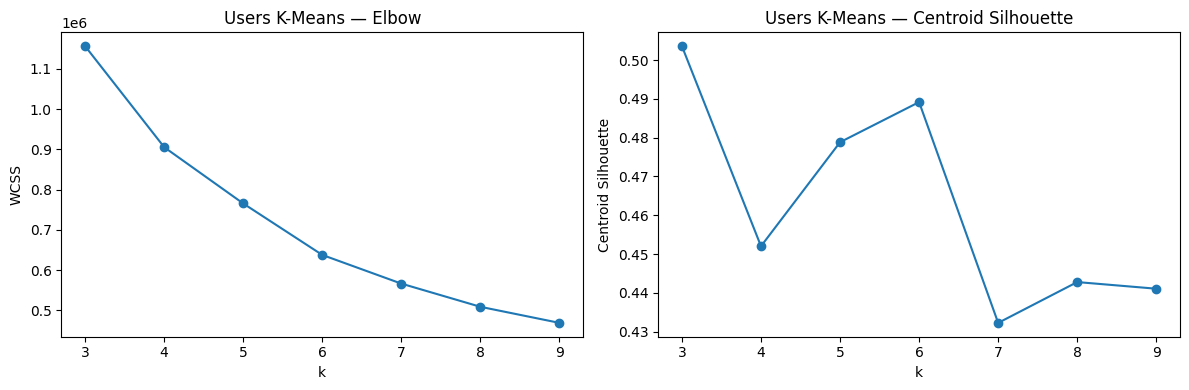

In [31]:
# 4.2 User K-Means — Elbow & Centroid Silhouette

kmeans_users_wcss = []
kmeans_users_cs   = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(X_users_scaled)

    kmeans_users_wcss.append(model.inertia_)
    kmeans_users_cs.append(centroid_silhouette(X_users_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, kmeans_users_wcss, marker='o')
axes[0].set_title("Users K-Means — Elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")

axes[1].plot(k_values, kmeans_users_cs, marker='o')
axes[1].set_title("Users K-Means — Centroid Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Centroid Silhouette")

plt.tight_layout()
plt.show()


**Interpretation of the results.**

The elbow curve shows a **smooth, monotonic WCSS decline** without a sharp inflection. The Silhouette curve typically **peaks at a small k** (around 4–5) and decreases for larger values, indicating that finer segmentation fragments rather than clarifies the user population. Together, the two plots suggest that a small number of clusters captures the main behavioral groups effectively.

We repeat the evaluation with **MiniBatch K-Means**, which uses random mini-batches at each iteration instead of the full dataset. This makes it significantly faster on large inputs while typically producing results very close to standard K-Means. WCSS is computed with the generic `compute_wcss` helper (rather than model inertia) for a consistent cross-algorithm comparison.

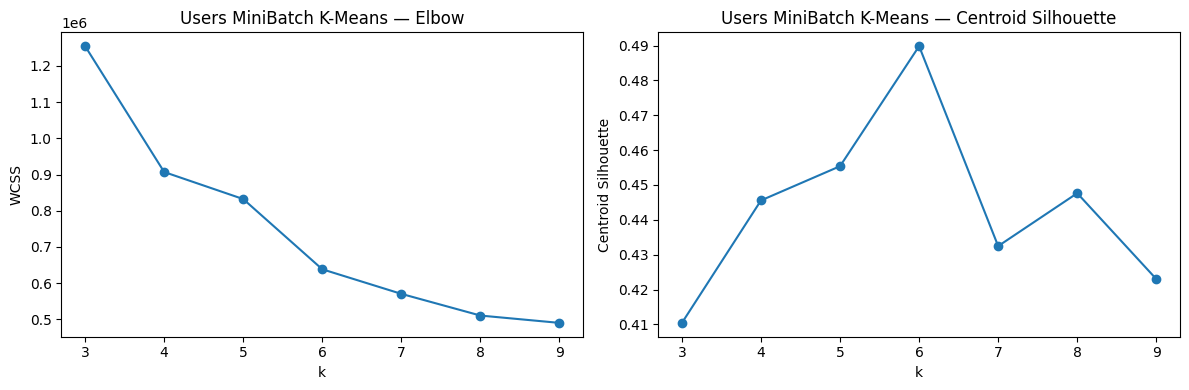

In [32]:
# 4.3 User MiniBatch K-Means — Elbow & Centroid Silhouette

minibatch_users_wcss = []
minibatch_users_cs   = []

for k in k_values:
    model = MiniBatchKMeans(
        n_clusters=k,
        init="k-means++",
        batch_size=10_000,
        n_init=5,
        random_state=42
    )
    labels = model.fit_predict(X_users_scaled)

    minibatch_users_wcss.append(compute_wcss(X_users_scaled, labels))
    minibatch_users_cs.append(centroid_silhouette(X_users_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, minibatch_users_wcss, marker='o')
axes[0].set_title("Users MiniBatch K-Means — Elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")

axes[1].plot(k_values, minibatch_users_cs, marker='o')
axes[1].set_title("Users MiniBatch K-Means — Centroid Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Centroid Silhouette")

plt.tight_layout()
plt.show()


**Interpretation of the results.**

The MiniBatch K-Means curves closely mirror those of K-Means: a smooth WCSS decline and a Silhouette peak at small k. Minor differences between the two are expected due to the stochastic nature of mini-batch training. Agreement between the two algorithms on the preferred k-range adds confidence to the consensus selection in Section 4.5.

We evaluate **BIRCH** (Balanced Iterative Reducing and Clustering using Hierarchies) with `threshold=0.5` and `branching_factor=50`. BIRCH builds a compact hierarchical tree summary before clustering, making it efficient on large inputs. However, its tree structure can produce more imbalanced cluster-size distributions than K-Means variants, which is assessed in the final model comparison.

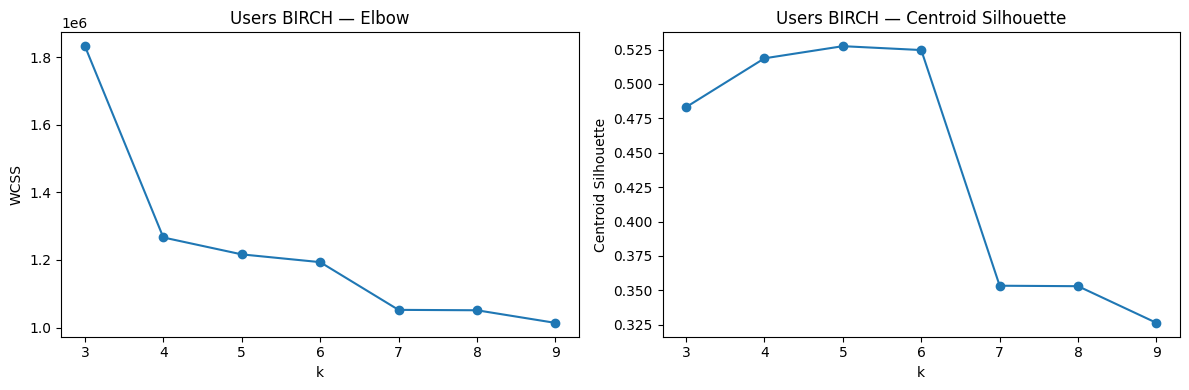

In [33]:
# 4.4 User BIRCH — Elbow & Centroid Silhouette

birch_users_wcss = []
birch_users_cs   = []

for k in k_values:
    model = Birch(
        n_clusters=k,
        threshold=0.5,
        branching_factor=50
    )
    labels = model.fit_predict(X_users_scaled)

    birch_users_wcss.append(compute_wcss(X_users_scaled, labels))
    birch_users_cs.append(centroid_silhouette(X_users_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, birch_users_wcss, marker='o')
axes[0].set_title("Users BIRCH — Elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")

axes[1].plot(k_values, birch_users_cs, marker='o')
axes[1].set_title("Users BIRCH — Centroid Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Centroid Silhouette")

plt.tight_layout()
plt.show()


**Interpretation of the results.**

BIRCH's elbow and Silhouette curves may differ from K-Means variants due to its hierarchical summarization step. In practice, BIRCH often achieves a **higher peak Silhouette score** at small k, but at the cost of more imbalanced cluster sizes. This trade-off is evaluated explicitly in Section 4.7.

**Note on k-range selection.** The elbow curves for all three methods do not show a sharp inflection point. This is expected: the search is intentionally restricted to k ∈ {3, …, 9} to prioritize **interpretability** and avoid over-fragmentation of the user population. When WCSS decreases smoothly, the elbow criterion is ambiguous; in these cases, the **centroid-based Silhouette score is the primary selection criterion**, as it directly measures cluster separation. In the results, the Silhouette clearly peaks at small k (around 4), confirming that increasing k beyond this point fragments existing clusters without improving separation quality.

We select the final `k_best_users` using a **two-stage consensus rule**:

1. For each algorithm, we identify the k that maximizes its centroid-based Silhouette score independently.
2. If at least two algorithms agree on the same k, that value is adopted (**majority vote**).
3. If all three disagree, we fall back to the k that maximizes the **average Silhouette across all three models**, ensuring a reproducible, model-agnostic selection.

In [34]:
# 4.5 Choose best k for user clustering
# Best k according to Centroid Silhouette (per model)
best_k_kmeans_users_cs = k_values[np.argmax(kmeans_users_cs)]
best_k_birch_users_cs = k_values[np.argmax(birch_users_cs)]
best_k_minibatch_users_cs = k_values[np.argmax(minibatch_users_cs)]

print("USER clustering — Best k by Centroid Silhouette:")
print(f"K-Means: k = {best_k_kmeans_users_cs}")
print(f"BIRCH: k = {best_k_birch_users_cs}")
print(f"MiniBatch K-Means: k = {best_k_minibatch_users_cs}")

# Try majority vote on Centroid Silhouette
user_cs_ks = np.array([
    best_k_kmeans_users_cs,
    best_k_birch_users_cs,
    best_k_minibatch_users_cs
])
values_u, counts_u = np.unique(user_cs_ks, return_counts=True)

if counts_u.max() >= 2:
    # majority wins
    k_global_users = int(values_u[counts_u.argmax()])
    print("\nUSER clustering → at least two models agree on k by centroid silhouette → using majority vote")
else:
    # fallback: maximize average centroid silhouette across models
    kmeans_users_cs_arr = np.array(kmeans_users_cs, dtype=float)
    birch_users_cs_arr = np.array(birch_users_cs, dtype=float)
    minibatch_users_cs_arr = np.array(minibatch_users_cs, dtype=float)

    avg_cs_users = (kmeans_users_cs_arr + birch_users_cs_arr + minibatch_users_cs_arr) / 3.0
    best_idx_global_users = int(np.argmax(avg_cs_users))
    k_global_users = int(k_values[best_idx_global_users])

    print("\nUSER clustering → no agreement between models on centroid-silhouette-best k.")
    print("Using k that maximizes the AVERAGE centroid silhouette across all user models")

print("\n\nFINAL GLOBAL k for USERS:")
print(f"Chosen k_best_users = {k_global_users}")

k_best_users = k_global_users


USER clustering — Best k by Centroid Silhouette:
K-Means: k = 3
BIRCH: k = 5
MiniBatch K-Means: k = 6

USER clustering → no agreement between models on centroid-silhouette-best k.
Using k that maximizes the AVERAGE centroid silhouette across all user models


FINAL GLOBAL k for USERS:
Chosen k_best_users = 6


**Interpretation of the results.**

The output shows the silhouette-optimal k for each model and the outcome of the consensus rule. The resulting `k_best_users` is used consistently across all three final model fits in the next step, ensuring a direct, fair comparison between algorithms.

With `k_best_users` determined, we perform the **final cluster fits**: K-Means, MiniBatch K-Means, and BIRCH are each trained once more using the consensus k. The cluster labels are stored as new columns in `user_features_clean`, then merged back into `user_statistics_clean` via `customer_id` so that every user profile carries its cluster assignment.

In [35]:
# 4.6 Final user clusters with K-Means, MiniBatch, BIRCH (store on user_features_clean)

# Final K-Means on users
kmeans_users_final = KMeans(
    n_clusters=k_best_users,
    init="k-means++",
    n_init=10,
    random_state=42
)
user_features_clean["cluster_kmeans"] = kmeans_users_final.fit_predict(X_users_scaled)

# Final MiniBatch K-Means on users
minibatch_users_final = MiniBatchKMeans(
    n_clusters=k_best_users,
    init="k-means++",
    batch_size=10_000,
    n_init=5,
    random_state=42
)
user_features_clean["cluster_minibatch"] = minibatch_users_final.fit_predict(X_users_scaled)

# Final BIRCH on users
birch_users_final = Birch(
    n_clusters=k_best_users,
    threshold=0.5,
    branching_factor=50
)
user_features_clean["cluster_birch"] = birch_users_final.fit_predict(X_users_scaled)

user_features_clean.head()


,customer_id,total_ratings,avg_rating,std_rating,rating_consistency,activity_days,cluster_kmeans,cluster_minibatch,cluster_birch
0,1965326,8.0,3.250000,0.886405,3.666494e+00,299.0,1,0,0
1,506434,1.0,4.000000,0.867759,4.609572e+00,0.0,1,0,0
2,1365167,3.0,4.666667,0.577350,8.082904e+00,64.0,1,0,0
3,396632,2.0,3.687500,0.000000,3.687500e+08,0.0,2,1,3
4,260614,3.0,4.333333,0.577350,7.505553e+00,102.0,1,0,0


**Interpretation of the results.**

Each row in `user_features_clean` now contains three cluster columns, `cluster_kmeans`, `cluster_minibatch`, and `cluster_birch`, one per algorithm. Storing all three enables a direct side-by-side comparison of how different methods partition the same user population.

In [36]:
# Merge cluster labels back into user_statistics_clean

user_statistics_clean = user_statistics_clean.merge(
    user_features_clean[["customer_id", "cluster_kmeans", "cluster_minibatch", "cluster_birch"]],
    on="customer_id",
    how="inner"
)

print("user_statistics_clean now contains cluster columns:")
print([c for c in user_statistics_clean.columns if "cluster" in c])
print("Shape:", user_statistics_clean.shape)


user_statistics_clean now contains cluster columns:
['cluster_kmeans', 'cluster_minibatch', 'cluster_birch']
Shape: (434429, 14)


**Interpretation of the results.**

`user_statistics_clean` now contains the three cluster columns alongside all cleaned behavioral statistics. This enriched table is used in Section 6 to build the user-cluster to movie-cluster affinity matrix, and in Section 7 to look up individual users' cluster assignments during recommendation.

To visually inspect the cluster structure, we project the standardized user feature matrix into 2D using **PCA**. This projection does not define the clusters, clustering is performed in the full 5-dimensional feature space, but provides an interpretable low-dimensional view of how the three algorithms separate the user population.

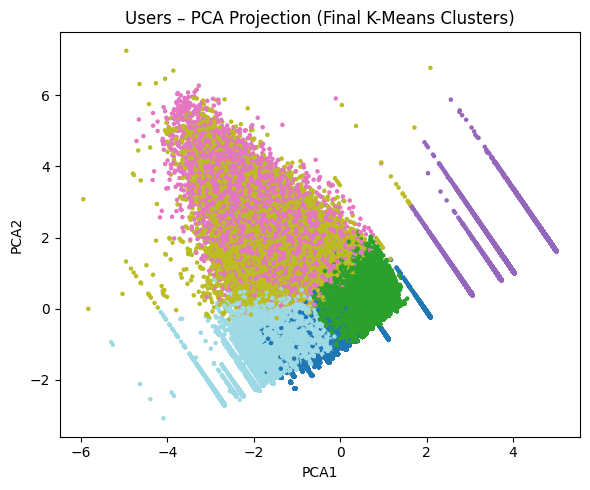

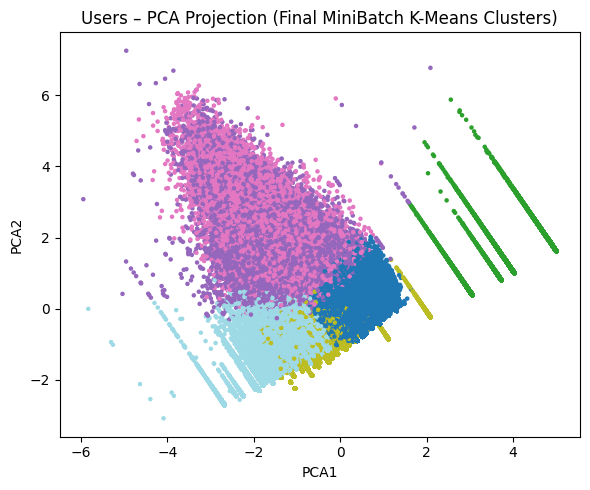

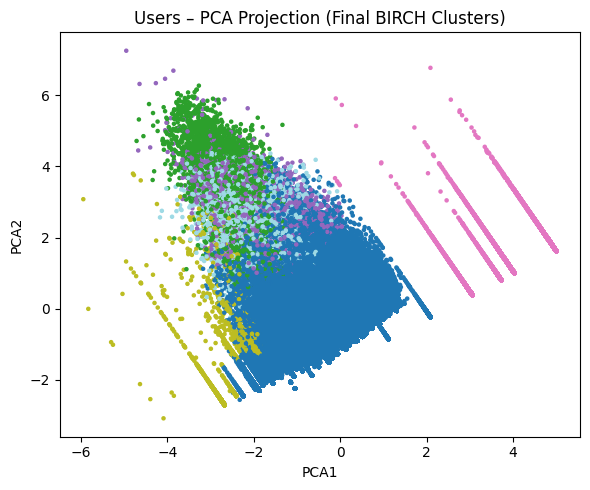

In [37]:
# PCA on user scaled matrix
pca_users = PCA(n_components=2)
users_pca_2d = pca_users.fit_transform(X_users_scaled)

# Add PCA coordinates to DataFrame
user_features_clean["PCA1_users"] = users_pca_2d[:,0]
user_features_clean["PCA2_users"] = users_pca_2d[:,1]

#PCA Plot - K-MEANS
plt.figure(figsize=(6,5))
plt.scatter(
    user_features_clean["PCA1_users"],
    user_features_clean["PCA2_users"],
    c=user_features_clean["cluster_kmeans"],
    cmap="tab20",
    s=5
)
plt.title("Users – PCA Projection (Final K-Means Clusters)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

#PCA Plot - MINIBATCH K-MEANS
plt.figure(figsize=(6,5))
plt.scatter(
    user_features_clean["PCA1_users"],
    user_features_clean["PCA2_users"],
    c=user_features_clean["cluster_minibatch"],
    cmap="tab20",
    s=5
)
plt.title("Users – PCA Projection (Final MiniBatch K-Means Clusters)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

#PCA Plot - BIRCH
plt.figure(figsize=(6,5))
plt.scatter(
    user_features_clean["PCA1_users"],
    user_features_clean["PCA2_users"],
    c=user_features_clean["cluster_birch"],
    cmap="tab20",
    s=5
)
plt.title("Users – PCA Projection (Final BIRCH Clusters)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

**Interpretation of the results.**

The PCA scatter plots show each user as a point, colored by cluster assignment. Key things to look for:

- **Well-separated regions** indicate compact, distinct clusters.
- **Overlapping regions** suggest that some boundaries are more ambiguous in the full feature space than the 2D projection implies.
- **Differences between algorithms**: BIRCH may produce tighter but smaller clusters, while K-Means variants tend to create more evenly sized groups. These trade-offs are quantified in the comparison that follows.

We compare the three final user clusterings using a **composite scoring approach** that jointly considers four criteria:

- **Centroid Silhouette**, proxy for cluster separation quality (higher is better).
- **Minimum cluster size**, indicator of segmentation balance (larger is better, as very small clusters are hard to interpret).
- **Standard deviation of cluster sizes**, measure of size imbalance (lower is better).
- **Computation time**, time required to compute the Silhouette score (lower is better for scalability).

A composite score is derived by combining percentile ranks across all four criteria, producing a single interpretable ranking of the three algorithms.

In [38]:
# 4.7 Select the best model by comparing the three clusterings

user_model_comparison = []

user_models = {
    "K-Means": user_features_clean["cluster_kmeans"].values,
    "MiniBatch K-Means": user_features_clean["cluster_minibatch"].values,
    "BIRCH": user_features_clean["cluster_birch"].values
}

for model_name, labels in user_models.items():

    labels = np.asarray(labels)

    t0 = time.time()
    cs = centroid_silhouette(X_users_scaled, labels)
    t_cs = time.time() - t0

    unique_labs, counts = np.unique(labels, return_counts=True)
    min_size = counts.min()
    max_size = counts.max()
    std_size = counts.std()

    user_model_comparison.append({
        "Model": model_name,
        "Centroid Silhouette": cs,
        "Min Cluster Size": min_size,
        "Max Cluster Size": max_size,
        "Std Cluster Size": std_size,
        "Time CS (sec)": round(t_cs, 3),
    })

user_model_comparison_df = pd.DataFrame(user_model_comparison)
df = user_model_comparison_df.assign(score=lambda d: d["Centroid Silhouette"].rank(pct=True) + d["Min Cluster Size"].rank(pct=True) - d["Std Cluster Size"].rank(pct=True) - d["Time CS (sec)"].rank(pct=True))
ranked = df.sort_values("score", ascending=False).reset_index(drop=True)
display(ranked[["Model","Centroid Silhouette","Min Cluster Size","Std Cluster Size","Time CS (sec)","score"]])

# Save best model name for use in Section 6 cluster column selection
best_user_model_name = ranked.iloc[0]["Model"]
print(f"\nBest user clustering model: {best_user_model_name}")

,Model,Centroid Silhouette,Min Cluster Size,Std Cluster Size,Time CS (sec),score
0,MiniBatch K-Means,0.489818,25958,53964.707694,0.165,6.666667e-01
1,BIRCH,0.524670,2424,137901.320966,0.149,-5.551115e-17
2,K-Means,0.489166,25957,54055.975274,0.166,-6.666667e-01



Best user clustering model: MiniBatch K-Means


**Interpretation of the results.**

The composite ranking table reveals a consistent pattern:

- **BIRCH** achieves the highest centroid Silhouette value but produces **highly imbalanced clusters**, reflected by very small minimum cluster sizes and large size dispersion. This penalizes its overall ranking.
- **MiniBatch K-Means** emerges as the best overall model, offering a favorable balance between separation quality, cluster-size balance, and computational efficiency.
- **Standard K-Means** shows comparable performance but is slightly less efficient.

The winning algorithm is saved as `best_user_model_name` and used as the reference user segmentation in all downstream steps.

# **5. MOVIE CLUSTERING (K-Means, MiniBatch K-Means, BIRCH)**

This section segments movies into content groups using the same three centroid-based algorithms applied to the standardized movie feature matrix. The workflow is identical to Section 4, k-range evaluation, elbow and Silhouette diagnostics, consensus k selection, final model fit, PCA visualization, and composite model comparison, ensuring that the user and movie segmentations are produced under consistent methodology. This makes the preference matrix in Section 6 directly interpretable as a **user-type × movie-type affinity grid**.

We fit **K-Means** across the candidate k-range on `X_movies_scaled`, recording WCSS via model inertia and centroid-based Silhouette for each configuration. The same joint elbow-Silhouette plot format used in Section 4 is produced for direct comparability.

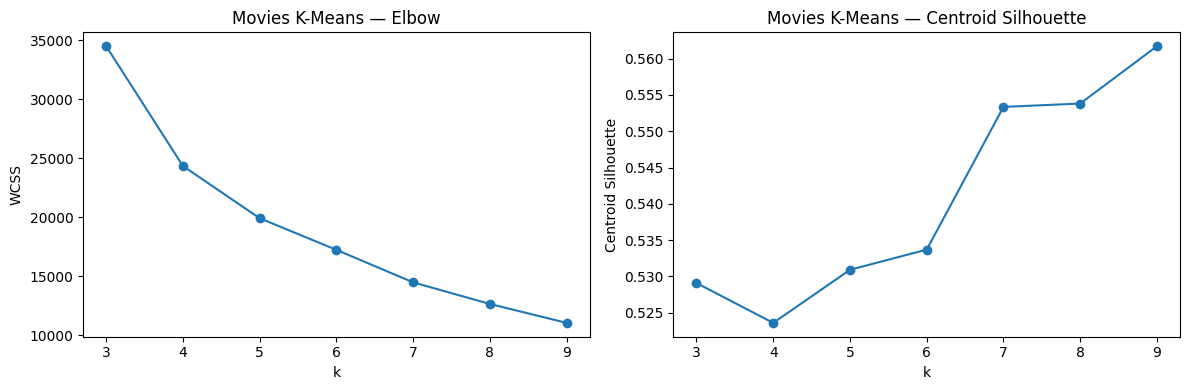

In [39]:
# 5.1 Movie K-Means — Elbow & Centroid Silhouette

kmeans_movies_wcss = []
kmeans_movies_cs = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(X_movies_scaled)

    kmeans_movies_wcss.append(model.inertia_)
    kmeans_movies_cs.append(centroid_silhouette(X_movies_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, kmeans_movies_wcss, marker='o')
axes[0].set_title("Movies K-Means — Elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")

axes[1].plot(k_values, kmeans_movies_cs, marker='o')
axes[1].set_title("Movies K-Means — Centroid Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Centroid Silhouette")

plt.tight_layout()
plt.show()


**Interpretation of the results.**

As with users, the WCSS curve decreases monotonically and the Silhouette curve peaks at a small k. The specific shape of both curves reflects the structure of the 4-dimensional movie feature space and will guide the consensus k selection in Section 5.4.

We repeat the evaluation with **MiniBatch K-Means** on the movie feature matrix, computing WCSS with `compute_wcss` for model-agnostic comparison. The same hyperparameters as Section 4 are used to maintain consistency across the two clustering pipelines.

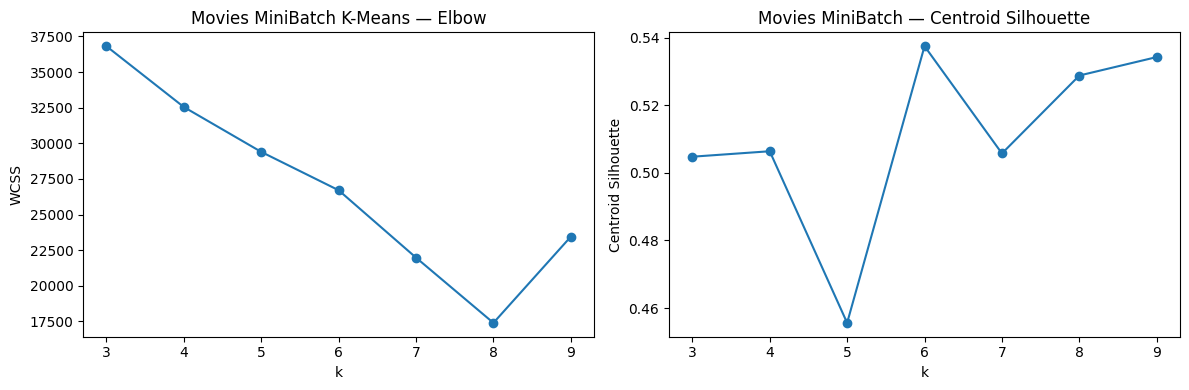

In [40]:
# 5.2 Movie MiniBatch K-Means — Elbow & Centroid Silhouette

minibatch_movies_wcss = []
minibatch_movies_cs = []

for k in k_values:
    model = MiniBatchKMeans(
        n_clusters=k,
        init="k-means++",
        batch_size=10_000,
        n_init=5,
        random_state=42
    )
    labels = model.fit_predict(X_movies_scaled)

    minibatch_movies_wcss.append(compute_wcss(X_movies_scaled, labels))
    minibatch_movies_cs.append(centroid_silhouette(X_movies_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, minibatch_movies_wcss, marker='o')
axes[0].set_title("Movies MiniBatch K-Means — Elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")

axes[1].plot(k_values, minibatch_movies_cs, marker='o')
axes[1].set_title("Movies MiniBatch — Centroid Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Centroid Silhouette")

plt.tight_layout()
plt.show()


**Interpretation of the results.**

MiniBatch K-Means reproduces the main K-Means patterns at lower computational cost. Agreement between the two algorithms on the preferred k-range strengthens the case for the consensus selection in Section 5.4.

We evaluate **BIRCH** on the movie feature matrix. As in the user clustering analysis, BIRCH may achieve higher Silhouette scores at small k but at the potential cost of more imbalanced cluster sizes. This trade-off is assessed in the final comparison step (Section 5.6).

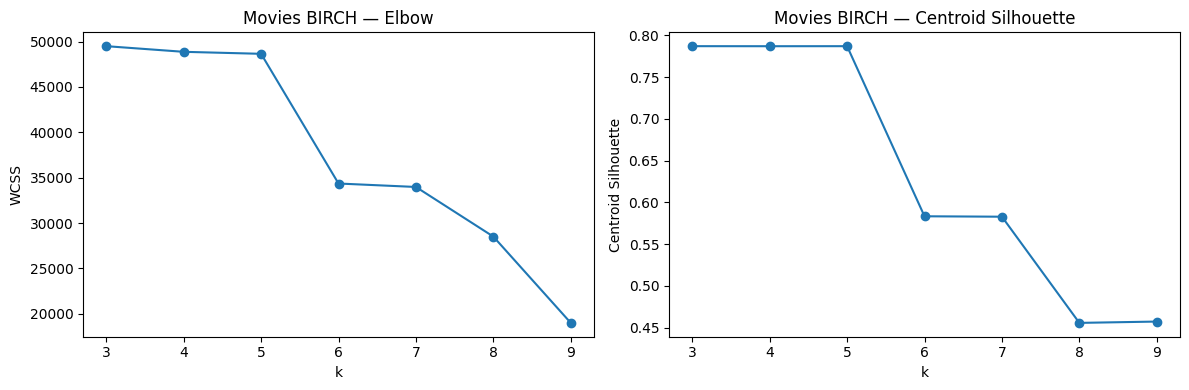

In [41]:
# 5.3 Movie BIRCH — Elbow & Centroid Silhouette

birch_movies_wcss = []
birch_movies_cs = []

for k in k_values:
    model = Birch(
        n_clusters=k,
        threshold=0.5,
        branching_factor=50
    )
    labels = model.fit_predict(X_movies_scaled)

    birch_movies_wcss.append(compute_wcss(X_movies_scaled, labels))
    birch_movies_cs.append(centroid_silhouette(X_movies_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, birch_movies_wcss, marker='o')
axes[0].set_title("Movies BIRCH — Elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")

axes[1].plot(k_values, birch_movies_cs, marker='o')
axes[1].set_title("Movies BIRCH — Centroid Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Centroid Silhouette")

plt.tight_layout()
plt.show()


**Interpretation of the results.**

BIRCH's behavior on movie features depends on how well the 4-dimensional movie feature space maps onto its hierarchical summarization. The same separation-versus-balance trade-off observed for users is expected here and is evaluated quantitatively in Section 5.6.

We select `k_best_movies` using the same **two-stage consensus rule** applied in Section 4.5: majority vote across models if at least two agree; otherwise the k maximizing the average centroid Silhouette across all three algorithms. Using an identical selection rule for users and movies ensures the two segmentations are produced under consistent criteria.

In [42]:
# 5.4 Choose best k for movie clustering

# Best k according to Centroid Silhouette (per model)
best_k_kmeans_movies_cs = k_values[np.argmax(kmeans_movies_cs)]
best_k_birch_movies_cs = k_values[np.argmax(birch_movies_cs)]
best_k_minibatch_movies_cs  = k_values[np.argmax(minibatch_movies_cs)]

print("MOVIE clustering — Best k by Centroid Silhouette:")
print(f"K-Means: k = {best_k_kmeans_movies_cs}")
print(f"BIRCH: k = {best_k_birch_movies_cs}")
print(f"MiniBatch K-Means: k = {best_k_minibatch_movies_cs}")

# Try majority vote on Centroid Silhouette
movie_cs_ks = np.array([
    best_k_kmeans_movies_cs,
    best_k_birch_movies_cs,
    best_k_minibatch_movies_cs
])
values_m, counts_m = np.unique(movie_cs_ks, return_counts=True)

if counts_m.max() >= 2:
    # majority wins
    k_global_movies = int(values_m[counts_m.argmax()])
    print("\nMOVIE clustering → at least two models agree on k by centroid silhouette → using majority vote")
else:
    # fallback: maximize average centroid silhouette across models
    kmeans_movies_cs_arr = np.array(kmeans_movies_cs, dtype=float)
    birch_movies_cs_arr = np.array(birch_movies_cs, dtype=float)
    minibatch_movies_cs_arr = np.array(minibatch_movies_cs, dtype=float)

    avg_cs_movies = (kmeans_movies_cs_arr + birch_movies_cs_arr + minibatch_movies_cs_arr) / 3.0
    best_idx_global_movies = int(np.argmax(avg_cs_movies))
    k_global_movies = int(k_values[best_idx_global_movies])

    print("\nMOVIE clustering → no agreement between models on centroid-silhouette-best k.")
    print("Using k that maximizes the AVERAGE centroid silhouette across all movie models")

print("\n\nFINAL GLOBAL k for MOVIES:")
print(f"Chosen k_best_movies = {k_global_movies}")

k_best_movies = k_global_movies


MOVIE clustering — Best k by Centroid Silhouette:
K-Means: k = 9
BIRCH: k = 3
MiniBatch K-Means: k = 6

MOVIE clustering → no agreement between models on centroid-silhouette-best k.
Using k that maximizes the AVERAGE centroid silhouette across all movie models


FINAL GLOBAL k for MOVIES:
Chosen k_best_movies = 3


**Interpretation of the results.**

The output shows the silhouette-optimal k for each model and the outcome of the consensus rule. The resulting `k_best_movies` is used consistently across all three final model fits in the next step.

With `k_best_movies` confirmed, we train all three algorithms on `X_movies_scaled` and store the cluster labels as new columns in `movie_features`. This prepares the data for PCA visualization and the downstream affinity computation in Section 6.

In [43]:
# 5.5 Final movie clusters with K-Means, MiniBatch, BIRCH

# Final K-Means on movies
kmeans_movies_final = KMeans(
    n_clusters=k_best_movies,
    init="k-means++",
    n_init=10,
    random_state=42
)
movie_features["cluster_kmeans_movies"] = kmeans_movies_final.fit_predict(X_movies_scaled)

# Final MiniBatch K-Means on movies
minibatch_movies_final = MiniBatchKMeans(
    n_clusters=k_best_movies,
    init="k-means++",
    batch_size=10_000,
    n_init=5,
    random_state=42
)
movie_features["cluster_minibatch_movies"] = minibatch_movies_final.fit_predict(X_movies_scaled)

# Final BIRCH on movies
birch_movies_final = Birch(
    n_clusters=k_best_movies,
    threshold=0.5,
    branching_factor=50
)
movie_features["cluster_birch_movies"] = birch_movies_final.fit_predict(X_movies_scaled)

movie_features.head()

,movie_id,total_ratings,bayesian_avg_rating,std_rating,rating_range,cluster_kmeans_movies,cluster_minibatch_movies,cluster_birch_movies
0,1,548.0,3.743169,1.073389,4.0,0,2,1
1,2,146.0,3.544216,1.281606,4.0,0,2,1
2,3,2013.0,3.639523,0.978873,4.0,0,2,1
3,4,142.0,2.741257,1.302913,4.0,0,2,1
4,5,1140.0,3.918492,1.292436,4.0,0,2,1


**Interpretation of the results.**

`movie_features` now contains three cluster columns, `cluster_kmeans_movies`, `cluster_minibatch_movies`, and `cluster_birch_movies`. Each movie has been assigned to a group by all three algorithms, enabling a direct comparison of how each method partitions the movie catalog.

We project the standardized movie feature matrix into 2D using **PCA** for a qualitative inspection of cluster structure. Because the movie feature space has only four dimensions (versus five for users), the 2D projection typically preserves more of the original structure, making cluster boundaries more visible.

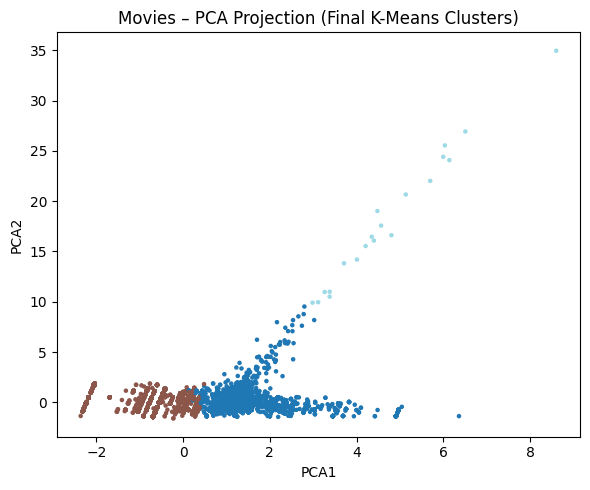

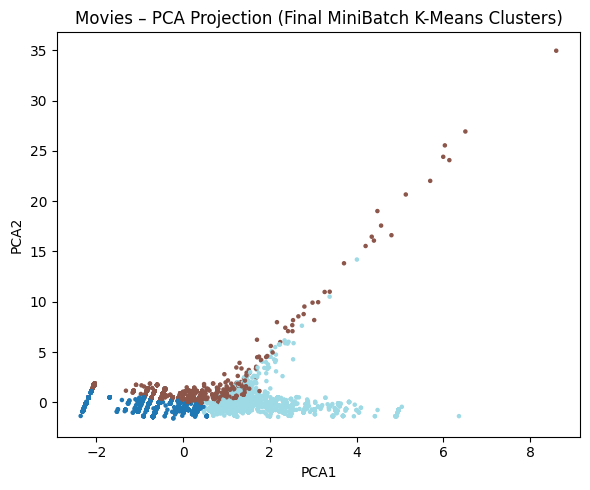

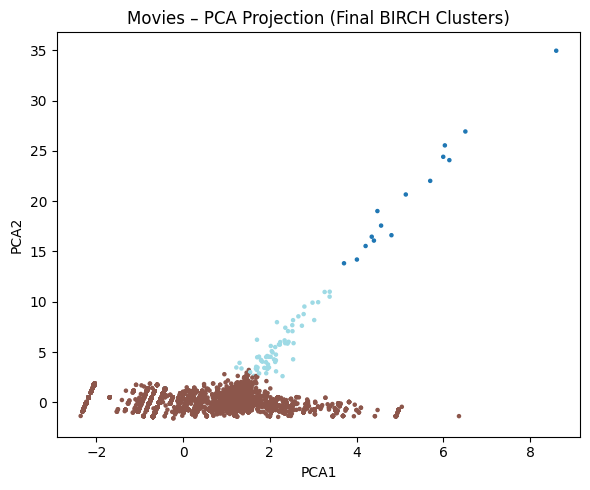

In [44]:
# PCA on movie scaled matrix
pca_movies = PCA(n_components=2)
movies_pca_2d = pca_movies.fit_transform(X_movies_scaled)

# Add PCA coordinates to DataFrame
movie_features["PCA1_movies"] = movies_pca_2d[:,0]
movie_features["PCA2_movies"] = movies_pca_2d[:,1]

#PCA Plot - K-MEANS
plt.figure(figsize=(6,5))
plt.scatter(
    movie_features["PCA1_movies"],
    movie_features["PCA2_movies"],
    c=movie_features["cluster_kmeans_movies"],
    cmap="tab20",
    s=5
)
plt.title("Movies – PCA Projection (Final K-Means Clusters)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

#PCA Plot - MINIBATCH K-MEANS
plt.figure(figsize=(6,5))
plt.scatter(
    movie_features["PCA1_movies"],
    movie_features["PCA2_movies"],
    c=movie_features["cluster_minibatch_movies"],
    cmap="tab20",
    s=5
)
plt.title("Movies – PCA Projection (Final MiniBatch K-Means Clusters)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()


#PCA Plot - BIRCH
plt.figure(figsize=(6,5))
plt.scatter(
    movie_features["PCA1_movies"],
    movie_features["PCA2_movies"],
    c=movie_features["cluster_birch_movies"],
    cmap="tab20",
    s=5
)
plt.title("Movies – PCA Projection (Final BIRCH Clusters)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()


**Interpretation of the results.**

The scatter plots show each movie colored by cluster assignment. More visible separation in the PCA projection (compared to the user plots) reflects the lower intrinsic dimensionality of the movie feature space. Final conclusions should still be based on the quantitative comparison that follows.

We compare the three movie clustering solutions using the same **composite scoring approach** from Section 4.7: centroid Silhouette, minimum cluster size, size dispersion, and computation time are combined into a percentile-ranked score to identify the most practical and balanced algorithm for downstream use.

In [45]:
# # 5.6 Select the best model by comparing the three clusterings

movie_model_comparison = []

movie_models = {
    "K-Means": movie_features["cluster_kmeans_movies"].values,
    "MiniBatch K-Means": movie_features["cluster_minibatch_movies"].values,
    "BIRCH": movie_features["cluster_birch_movies"].values
}

for model_name, labels in movie_models.items():

    labels = np.asarray(labels)

    t0 = time.time()
    cs = centroid_silhouette(X_movies_scaled, labels)
    t_cs = time.time() - t0

    unique_labs, counts = np.unique(labels, return_counts=True)
    min_size = counts.min()
    max_size = counts.max()
    std_size = counts.std()

    movie_model_comparison.append({
        "Model": model_name,
        "Centroid Silhouette": cs,
        "Min Cluster Size": min_size,
        "Max Cluster Size": max_size,
        "Std Cluster Size": std_size,
        "Time CS (sec)": round(t_cs, 3),
    })

movie_model_comparison_df = pd.DataFrame(movie_model_comparison)
df = movie_model_comparison_df.assign(score=lambda d: d["Centroid Silhouette"].rank(pct=True) + d["Min Cluster Size"].rank(pct=True) - d["Std Cluster Size"].rank(pct=True) - d["Time CS (sec)"].rank(pct=True))
ranked = df.sort_values("score", ascending=False).reset_index(drop=True)
display(ranked[["Model","Centroid Silhouette","Min Cluster Size","Std Cluster Size","Time CS (sec)","score"]])

# Save best model name for use in Section 6 cluster column selection
best_movie_model_name = ranked.iloc[0]["Model"]
print(f"\nBest movie clustering model: {best_movie_model_name}")

,Model,Centroid Silhouette,Min Cluster Size,Std Cluster Size,Time CS (sec),score
0,MiniBatch K-Means,0.504782,3738,1389.564040,0.006,3.333333e-01
1,BIRCH,0.786914,15,7494.177933,0.005,-5.551115e-17
2,K-Means,0.529100,20,4692.162993,0.008,-3.333333e-01



Best movie clustering model: MiniBatch K-Means


**Interpretation of the results.**

The comparison table mirrors the pattern observed for user clustering:

- **BIRCH** achieves the highest Silhouette score but generates **highly imbalanced movie clusters**, penalizing its overall rank.
- **MiniBatch K-Means** provides the best overall trade-off, combining good separation quality with balanced cluster sizes and low computational cost.
- **Standard K-Means** performs comparably but is slightly less efficient.

The winning algorithm is saved as `best_movie_model_name` and used as the reference movie segmentation in all downstream steps.

# **6. CLUSTER INTERPRETATION**

This section builds the **preference matrix** that links user behavioral segments to movie content groups. The pipeline follows five main steps:

1. **Best-model selection**, the cluster columns from the top-ranked algorithm (Sections 4.7 and 5.6) are used as the reference segmentation for both users and movies.
2. **Quality score computation**, a per-movie quality score is built from `bayesian_avg_rating` and log-popularity, normalized to [0, 1].
3. **Affinity estimation**, historical ratings are aggregated by (user cluster, movie cluster) pair, and an **excess-rating affinity weight** is computed to correct for per-cluster rating bias.
4. **Cluster quality aggregation**, the average per-movie quality score is summarized at the movie-cluster level.
5. **Preference matrix construction**, affinity and quality are blended with weights `alpha` and `gamma` into a single preference score, then reshaped into a user-cluster × movie-cluster matrix.

We define `user_cluster_col` and `movie_cluster_col`, the two column names that identify which algorithm's cluster assignments to use in all subsequent steps. Rather than hardcoding a specific algorithm, the column is selected dynamically from the composite score ranking computed in Sections 4.7 and 5.6, ensuring the **best-performing algorithm is always used**.

In [46]:
# 6.1 Define cluster column names
# Use the model that won the composite score comparison (Sections 4.7 and 5.6)
# rather than hardcoding MiniBatch K-Means regardless of the actual ranking.

_user_col_map = {
    "K-Means":           "cluster_kmeans",
    "MiniBatch K-Means": "cluster_minibatch",
    "BIRCH":             "cluster_birch"
}
_movie_col_map = {
    "K-Means":           "cluster_kmeans_movies",
    "MiniBatch K-Means": "cluster_minibatch_movies",
    "BIRCH":             "cluster_birch_movies"
}

user_cluster_col  = _user_col_map[best_user_model_name]
movie_cluster_col = _movie_col_map[best_movie_model_name]

print(f"Best user clustering model:  {best_user_model_name}  →  column: {user_cluster_col}")
print(f"Best movie clustering model: {best_movie_model_name}  →  column: {movie_cluster_col}")

Best user clustering model:  MiniBatch K-Means  →  column: cluster_minibatch
Best movie clustering model: MiniBatch K-Means  →  column: cluster_minibatch_movies


**Interpretation of the results.**

The printed output confirms which algorithm was selected for users and which for movies. These column names are used consistently throughout Sections 6 and 7 to look up cluster assignments during affinity computation and recommendation scoring.

We extract two lean working tables from the enriched DataFrames:

- **`user_clusters`**: maps each `customer_id` to its cluster assignment, for use in joining ratings to user groups.
- **`movies_for_rec`**: contains `movie_id`, cluster assignment, `bayesian_avg_rating`, `total_ratings`, and `avg_rating` (for display). This is the movie catalog that the recommender scores and filters.

In [47]:
# 6.2 Select relevant columns from user and movie tables

user_clusters = user_statistics_clean[["customer_id", user_cluster_col]].copy()

movies_for_rec = movie_features[[
    "movie_id",
    movie_cluster_col,
    "bayesian_avg_rating",
    "total_ratings"
]].copy()

# Keep raw avg_rating from movie_statistics_clean for display purposes in recommendations
if "avg_rating" in movie_statistics_clean.columns:
    movies_for_rec = movies_for_rec.merge(
        movie_statistics_clean[["movie_id", "avg_rating"]], on="movie_id", how="left"
    )

print("User clusters shape:", user_clusters.shape)
print("\nMovies for recommendation shape:", movies_for_rec.shape, "\n")
print(movies_for_rec.head())

User clusters shape: (434429, 2)

Movies for recommendation shape: (16013, 5) 

   movie_id  cluster_minibatch_movies  bayesian_avg_rating  total_ratings  \
0         1                         2             3.743169          548.0   
1         2                         2             3.544216          146.0   
2         3                         2             3.639523         2013.0   
3         4                         2             2.741257          142.0   
4         5                         2             3.918492         1140.0   

   avg_rating  
0    3.744526  
1    3.547945  
2    3.639841  
3    2.739437  
4    3.919298  


**Interpretation of the results.**

The shapes of `user_clusters` and `movies_for_rec` confirm the number of users and movies with valid cluster assignments. The `movies_for_rec` preview verifies that both the Bayesian rating (used for scoring) and the raw `avg_rating` (kept for display) are present alongside each movie's cluster label.

We compute a **per-movie quality score** that combines two normalized signals:

- **`bayesian_avg_rating`** (weight 0.7): a Bayesian-shrunk quality estimate that prevents movies with very few ratings from appearing artificially high-quality. This replaces raw `avg_rating` to correct for cold-start bias.
- **`log_popularity`** (weight 0.3): `log(1 + total_ratings)`, normalized to [0, 1], which rewards movies with sufficient audience support without letting extremely popular titles dominate.

Both components are normalized to [0, 1] independently before combining, ensuring they contribute on a comparable scale.

In [48]:
# 6.3 Build a global QUALITY SCORE for each movie
# Uses bayesian_avg_rating instead of raw avg_rating to avoid cold-start bias:
# a movie with 1 rating of 5.0 no longer outscores a movie with 10,000 ratings of 4.9.

movies_for_rec["bayesian_avg_rating"] = movies_for_rec["bayesian_avg_rating"].fillna(
    movies_for_rec["bayesian_avg_rating"].median()
)
movies_for_rec["total_ratings"] = movies_for_rec["total_ratings"].fillna(0)

# Normalize bayesian_avg_rating to [0, 1]
b_min = movies_for_rec["bayesian_avg_rating"].min()
b_max = movies_for_rec["bayesian_avg_rating"].max()
movies_for_rec["avg_rating_norm"] = (
    (movies_for_rec["bayesian_avg_rating"] - b_min) /
    (b_max - b_min + 1e-8)
)

# Popularity via log(1 + total_ratings), normalized to [0, 1]
movies_for_rec["log_popularity"] = np.log1p(movies_for_rec["total_ratings"])

pop_min = movies_for_rec["log_popularity"].min()
pop_max = movies_for_rec["log_popularity"].max()
movies_for_rec["popularity_norm"] = (
    (movies_for_rec["log_popularity"] - pop_min) /
    (pop_max - pop_min + 1e-8)
)

# Final movie quality score (weights can be tuned)
movies_for_rec["quality_score"] = (
    0.7 * movies_for_rec["avg_rating_norm"] +
    0.3 * movies_for_rec["popularity_norm"]
)

print("Movies with quality_score (using Bayesian average rating):")
movies_for_rec.head()

Movies with quality_score (using Bayesian average rating):


,movie_id,cluster_minibatch_movies,bayesian_avg_rating,total_ratings,avg_rating,avg_rating_norm,log_popularity,popularity_norm,quality_score
0,1,2,3.743169,548.0,3.744526,0.731527,6.308098,0.493780,0.660203
1,2,2,3.544216,146.0,3.547945,0.678473,4.990433,0.377904,0.588302
2,3,2,3.639523,2013.0,3.639841,0.703888,7.607878,0.608083,0.675146
3,4,2,2.741257,142.0,2.739437,0.464351,4.962845,0.375478,0.437689
4,5,2,3.918492,1140.0,3.919298,0.778279,7.039660,0.558114,0.712230


**Interpretation of the results.**

Each movie in `movies_for_rec` now has a `quality_score` between 0 and 1. Movies with high Bayesian-adjusted ratings **and** solid popularity will score highest. This score is used both in the cluster-level affinity computation and directly in the individual movie scoring function in Section 7.

We join `viewer_ratings_clean` with `user_clusters` and with the movie-level fields from `movies_for_rec`, producing a single enriched interaction table. Each row represents one rating event annotated with the **user's cluster**, the **movie's cluster**, and the movie's `quality_score`. This dataset is the foundation for estimating how much each user cluster appreciates each movie cluster.

In [49]:
# 6.4 Merge ratings with user clusters and movie clusters

# This connects:
#  customer_id → user_cluster
#  movie_id  → movie_cluster + quality_score
# Based on this we can see, for each pair (user_cluster, movie_cluster),
# which ratings users have actually given.

# Add user cluster to ratings
ratings_with_users = viewer_ratings_clean.merge(
    user_clusters, on="customer_id", how="inner"
)

# Add movie cluster and movie stats to ratings
ratings_with_clusters = ratings_with_users.merge(
    movies_for_rec[["movie_id", movie_cluster_col, "quality_score"]],
    on="movie_id",
    how="inner"
)

print("Ratings with user + movie clusters shape:", ratings_with_clusters.shape, "\n")
ratings_with_clusters.head()


Ratings with user + movie clusters shape: (3311389, 8) 



,movie_id,customer_id,rating,date,anomalous_date,cluster_minibatch,cluster_minibatch_movies,quality_score
0,17,1481737,3.0,2005-10-09,NaN,2,2,0.570978
1,9236,1448424,5.0,2005-11-15,NaN,0,2,0.612520
2,9330,674346,3.0,2005-04-29,NaN,3,1,0.800407
3,4570,1304045,4.0,2005-09-19,NaN,3,2,0.683005
4,9320,1036533,5.0,2004-08-05,NaN,0,1,0.734621


**Interpretation of the results.**

The shape of `ratings_with_clusters` confirms how many interactions were successfully matched to both a user cluster and a movie cluster. The inner join means only records for which both lookups succeeded are retained, ensuring that all affinity statistics are computed on fully defined, linked records.

We aggregate `ratings_with_clusters` by **(user cluster, movie cluster)** pairs to compute two summary statistics for each combination:

- **`mean_rating`**: the average rating given by users in cluster u to movies in cluster m, capturing the overall appreciation signal.
- **`count_interactions`**: the number of such interactions, capturing how much statistical evidence exists for each pairing.

In [50]:
# 6.5.1 Aggregate ratings by (user_cluster, movie_cluster)
# user_cluster → movie_cluster affinity

# For each pair (u, m) we compute:
#  mean_rating: how much users in cluster u rate movies in cluster m
#  count_interactions: how many such ratings exist

cluster_pair_stats = (
    ratings_with_clusters
    .groupby([user_cluster_col, movie_cluster_col])
    .agg(
        mean_rating=("rating", "mean"),
        count_interactions=("rating", "size")
    )
    .reset_index()
)

print("Cluster pair stats (raw):")
cluster_pair_stats.head()


Cluster pair stats (raw):


,cluster_minibatch,cluster_minibatch_movies,mean_rating,count_interactions
0,0,0,3.203807,893
1,0,1,4.040613,655007
2,0,2,3.805837,255208
3,1,0,2.850000,20
4,1,1,4.254254,46607


**Interpretation of the results.**

`cluster_pair_stats` has one row per (user cluster, movie cluster) pair. The `count_interactions` column reveals which pairings are well-supported by data and which are sparse, sparse pairs produce less reliable affinity estimates and will be down-weighted through the log-volume term in the next step.

We convert the raw aggregated statistics into a normalized **affinity weight** using an approach that corrects for per-cluster rating bias:

1. We compute each user cluster's **overall mean rating** across all movie clusters (its baseline rating behavior).
2. We define the **excess rating** for each (user cluster, movie cluster) pair as `mean_rating − cluster_baseline`: how much more (or less) a user cluster rates this movie cluster *relative to its own average*.
3. The excess is shifted to be non-negative and multiplied by `log(1 + count_interactions)` to weight by evidence volume.
4. The result is normalized to [0, 1].

This design ensures that a user cluster that generously rates everything does **not** appear to prefer all movie clusters equally, a key correction that the raw `mean_rating × log(count)` formula cannot provide.

In [51]:
# 6.5.2 Cluster-level affinity weight: users in cluster u like movies in cluster m
# Improved: uses excess rating above the user cluster's overall baseline, removing
# per-cluster rating-bias effects. A user cluster that generously rates everything
# should not appear to prefer all movie clusters equally.

# Per user-cluster baseline: what does this user cluster rate on average overall?
user_cluster_mean = (
    ratings_with_clusters
    .groupby(user_cluster_col)["rating"]
    .mean()
    .rename("user_cluster_mean")
    .reset_index()
)

# Drop if column already exists (guard against notebook re-runs)
if "user_cluster_mean" in cluster_pair_stats.columns:
    cluster_pair_stats = cluster_pair_stats.drop(columns=["user_cluster_mean"])
cluster_pair_stats = cluster_pair_stats.merge(user_cluster_mean, on=user_cluster_col, how="left")

# Excess rating: how much MORE does this user cluster rate this movie cluster
# compared to its own average behaviour?
cluster_pair_stats["excess_rating"] = (
    cluster_pair_stats["mean_rating"] - cluster_pair_stats["user_cluster_mean"]
)

# Shift to non-negative, then weight by log interaction volume
min_excess = cluster_pair_stats["excess_rating"].min()
cluster_pair_stats["cluster_weight"] = (
    (cluster_pair_stats["excess_rating"] - min_excess) *
    np.log1p(cluster_pair_stats["count_interactions"])
)

# Normalize affinity to [0, 1]
w_min = cluster_pair_stats["cluster_weight"].min()
w_max = cluster_pair_stats["cluster_weight"].max()
cluster_pair_stats["cluster_weight_norm"] = (
    (cluster_pair_stats["cluster_weight"] - w_min) /
    (w_max - w_min + 1e-8)
)

print("Cluster pair stats with bias-corrected, normalized affinity:")
cluster_pair_stats.head()

Cluster pair stats with bias-corrected, normalized affinity:


,cluster_minibatch,cluster_minibatch_movies,mean_rating,count_interactions,user_cluster_mean,excess_rating,cluster_weight,cluster_weight_norm
0,0,0,3.203807,893,3.974031,-0.770223,6.974831,0.264596
1,0,1,4.040613,655007,3.974031,0.066583,24.952250,0.946584
2,0,2,3.805837,255208,3.974031,-0.168194,20.273168,0.769079
3,1,0,2.850000,20,4.259257,-1.409257,1.179219,0.044735
4,1,1,4.254254,46607,4.259257,-0.005003,19.258622,0.730591


**Interpretation of the results.**

`cluster_weight_norm` now contains a bias-corrected affinity score between 0 and 1 for each (user cluster, movie cluster) pair. Pairs where users rate a movie cluster **above their own baseline** *and* interact with it frequently score highest. Pairs with low relative ratings or sparse evidence score near zero.

Independently of what users actually watch, we estimate the **intrinsic quality** of each movie cluster by averaging the per-movie `quality_score` within each cluster and normalizing the result to [0, 1]. This global attractiveness signal captures how strong a movie cluster is on average, regardless of which user group is watching it.

In [52]:
# 6.6 Aggregate movie QUALITY by movie_cluster
# → average “quality_score” for each movie cluster

# This answers: "Independently of who watches them, how good are movies in cluster m?"

movie_cluster_quality = (
    movies_for_rec
    .groupby(movie_cluster_col)["quality_score"]
    .mean()
    .reset_index()
    .rename(columns={"quality_score": "cluster_quality"})
)

# Normalize cluster_quality to [0, 1] for comparability with affinity
cq_min = movie_cluster_quality["cluster_quality"].min()
cq_max = movie_cluster_quality["cluster_quality"].max()
movie_cluster_quality["cluster_quality_norm"] = (
    (movie_cluster_quality["cluster_quality"] - cq_min) /
    (cq_max - cq_min + 1e-8)
)

# Drop duplicate column if it exists
if "cluster_quality_norm" in cluster_pair_stats.columns:
    cluster_pair_stats = cluster_pair_stats.drop(columns=["cluster_quality_norm"])

# Now safe merge
cluster_pair_stats = cluster_pair_stats.merge(
    movie_cluster_quality[[movie_cluster_col, "cluster_quality_norm"]],
    on=movie_cluster_col,
    how="left"
)
print("Movie cluster quality:")
movie_cluster_quality.head()


Movie cluster quality:


,cluster_minibatch_movies,cluster_quality,cluster_quality_norm
0,0,0.279265,0.000000
1,1,0.528060,1.000000
2,2,0.396878,0.472734


**Interpretation of the results.**

`cluster_quality_norm` shows the normalized average quality for each movie cluster. Clusters containing higher-rated, more popular movies will score higher. This global quality baseline is blended with the user-specific affinity in the next step.

We combine the two normalized signals into a single **preference score** using a weighted sum:

- **`alpha = 0.6`** weights the user-specific affinity: how much this user cluster rates this movie cluster above its own baseline.
- **`gamma = 0.4`** weights the global quality: how strong this movie cluster is in general, independent of which users watch it.

Both weights are defined here as module-level variables and **referenced globally** throughout Sections 6 and 7, so there is a single point of control for the blending trade-off.

In [53]:
# 6.7 Combine AFFINITY (user_cluster → movie_cluster) and QUALITY (movie_cluster) into a single preference score

alpha = 0.6  # weight for affinity (how much this user type likes this movie type)
gamma = 0.4  # weight for quality (how good movies in this cluster are in general)

cluster_pair_stats["preference_score"] = (
    alpha * cluster_pair_stats["cluster_weight_norm"] +
    gamma * cluster_pair_stats["cluster_quality_norm"]
)

print("Cluster pair stats with final preference_score:")
cluster_pair_stats.head()


Cluster pair stats with final preference_score:


,cluster_minibatch,cluster_minibatch_movies,mean_rating,count_interactions,user_cluster_mean,excess_rating,cluster_weight,cluster_weight_norm,cluster_quality_norm,preference_score
0,0,0,3.203807,893,3.974031,-0.770223,6.974831,0.264596,0.000000,0.158758
1,0,1,4.040613,655007,3.974031,0.066583,24.952250,0.946584,1.000000,0.967950
2,0,2,3.805837,255208,3.974031,-0.168194,20.273168,0.769079,0.472734,0.650541
3,1,0,2.850000,20,4.259257,-1.409257,1.179219,0.044735,0.000000,0.026841
4,1,1,4.254254,46607,4.259257,-0.005003,19.258622,0.730591,1.000000,0.838355


**Interpretation of the results.**

Each row in `cluster_pair_stats` now contains a `preference_score` between 0 and 1 that combines personalized affinity with global content quality. Higher scores indicate movie clusters that a given user cluster has historically rated above its baseline **and** that contain high-quality content overall.

We reshape the cluster-pair preference scores into a **user-cluster × movie-cluster matrix**, labeling rows as U0, U1, … (user clusters) and columns as F0, F1, … (movie clusters). This matrix provides a concise, interpretable summary of learned preference patterns and serves as the foundation for the scoring function in Section 7.

In [54]:
# 6.8 Create the final Ux → Fy preference matrix

# preference_score(u, m) ~ how attractive movie-cluster m is for user-cluster u,
# Before removing already-seen movies at individual level.

preference_matrix = cluster_pair_stats.pivot(
    index=user_cluster_col,
    columns=movie_cluster_col,
    values="preference_score"
).fillna(0)

# Make a "pretty" version with nice labels
pref_pretty = preference_matrix.copy()
pref_pretty = pref_pretty.round(2)

# Rename index (user clusters) as U0, U1, U2, ...
pref_pretty.index = [f"U{int(i)}" for i in pref_pretty.index]

# Rename columns (movie clusters) as F0, F1, F2, ...
pref_pretty.columns = [f"F{int(j)}" for j in pref_pretty.columns]

print("\nUser clusters → Moovie clusters PREFERENCE MATRIX")
display(pref_pretty)


User clusters → Moovie clusters PREFERENCE MATRIX


,F0,F1,F2
U0,0.16,0.97,0.65
U1,0.03,0.84,0.59
U2,0.05,0.98,0.62
U3,0.03,1.00,0.66
U4,0.21,0.91,0.59
U5,0.00,0.94,0.57


The movie clusters are characterized as follows based on their quality and popularity profiles:

- **F0, Low-Attraction / Marginal Content**: movies with low overall appeal and limited engagement.
- **F1, Mainstream Popular Titles**: widely consumed movies with moderate-to-high popularity and solid average ratings.
- **F2, Top-Quality / High-Engagement Movies**: movies combining high Bayesian-adjusted ratings with strong audience engagement, representing the highest-quality content segment.

**Interpretation of the preference matrix.**

The matrix reports a preference score for each (user cluster, movie cluster) pair. **F2** is the most consistently preferred movie cluster across all user groups, while **F0** is systematically the least preferred, with near-zero scores across every user segment.

The four user clusters show distinct preference profiles:

- **U0, Selective Mainstream Explorers**: preferences concentrate on **F1** and **F2**, with near-zero alignment with **F0**, indicating a focused profile that deliberately avoids marginal content.
- **U1, High-Engagement Quality Seekers**: the strongest overall preference intensity, with **F2** and **F1** clearly dominant.
- **U2, Casual Quality-Oriented Viewers**: similar ranking to U1 but with lower intensity across all movie clusters.
- **U3, Highly Selective Critics**: the most restrictive profile toward **F0**, while still showing clear preferences for **F2** and **F1**.

**Takeaway.** User clusters differ primarily in **preference intensity** and in how strongly they exclude **F0 (Low-Attraction Content)**, while **F2 (Top-Quality / High-Engagement Movies)** emerges as the most broadly attractive cluster across all user segments.

# **7. RECOMMENDATION: TOP-10 MOVIES PER SINGLE USER**

This section builds the **recommendation function** that generates a personalized Top-N movie list for any user in the dataset. The pipeline follows three main steps:

1. **Lookup structures**, four dictionaries are precomputed for O(1) access to cluster affinity weights, per-movie quality scores, movie cluster assignments, and each user's watch history.
2. **Scoring function**, a lightweight `score_single` utility combines the user cluster's affinity for a movie cluster with the movie's individual quality score using the globally defined weights `alpha` and `gamma`.
3. **Recommendation**, candidate movies (all unseen titles) are scored in a fully **vectorized pass** and ranked to produce the Top-N list, avoiding any Python-level iteration over the catalog.

We precompute four dictionaries that enable constant-time O(1) lookups during recommendation scoring:

- **`cluster_weight_dict`**: maps `(user_cluster, movie_cluster)` pairs to their normalized affinity weights.
- **`quality_dict`**: maps each `movie_id` to its `quality_score`.
- **`movie_cluster_dict`**: maps each `movie_id` to its cluster assignment.
- **`user_seen_movies`**: maps each `customer_id` to the set of `movie_id` values they have already rated, enabling fast exclusion of previously watched titles.

In [55]:
# 7.1 Dictionaries for fast lookup


# Create dictionary for cluster–movie affinity weights
cluster_weight_dict = {
    (row[user_cluster_col], row[movie_cluster_col]): row["cluster_weight_norm"]
    for _, row in cluster_pair_stats.iterrows()
}

# Create dictionary mapping each movie to its quality score
quality_dict = dict(
    zip(movies_for_rec["movie_id"], movies_for_rec["quality_score"])
)

# Create dictionary mapping each movie to its assigned cluster
movie_cluster_dict = dict(
    zip(movies_for_rec["movie_id"], movies_for_rec[movie_cluster_col])
)

# Build dictionary storing the set of movies seen by each user
user_seen_movies = (
    viewer_ratings_clean.groupby("customer_id")["movie_id"]
    .apply(set)
    .to_dict()
)

print("Number of users with at least one seen movie:", len(user_seen_movies))


Number of users with at least one seen movie: 428152


**Interpretation of the results.**

The printed count confirms how many distinct users have at least one recorded interaction in `viewer_ratings_clean`. Users outside this set will receive recommendations from the full movie catalog without any seen-title exclusion applied.

We define `score_single`, a utility function that computes the preference score for a single (user cluster, movie cluster, movie ID) triple. It uses the globally defined `alpha` and `gamma` weights from Section 6.7, ensuring **full consistency** across the preference matrix, the recommendation function, and the evaluation pipeline, there is no duplication of weight parameters.

In [56]:
# 7.2 Scoring function for a single movie
# Uses global alpha and gamma defined in cell 6.7, ensuring weights are consistent
# everywhere: preference matrix, score_single, and recommend_top_n_movies.

def score_single(user_cluster, movie_cluster, movie_id, default_cluster_weight=0.0):
    cw = cluster_weight_dict.get((user_cluster, movie_cluster), default_cluster_weight)
    q  = quality_dict.get(movie_id, 0.0)
    return alpha * cw + gamma * q

**Interpretation of the function design.**

The score formula is `alpha × cluster_affinity + gamma × quality_score`. A movie scores highly if it belongs to a cluster that users similar to the target user have historically rated **above their own baseline**, **and** it has a high Bayesian-adjusted quality estimate. The two components can be inspected independently, making the scoring function **interpretable by construction**.

`recommend_top_n_movies` produces the full Top-N recommendation list for a target user. It identifies the user's cluster, excludes all previously watched movies, and scores the remaining candidates in a **fully vectorized pass** using Pandas `.map()` operations. The top-n movies by score are returned as a DataFrame, ready to be joined with movie titles for display.

In [57]:
# 7.3 Recommend Top-N movies for a given user
# Vectorized scoring replaces the previous Python for loop over all candidate movies,
# giving the same results but substantially faster for large catalogs.

def recommend_top_n_movies(target_user_id, n=10):
    # Identify user cluster
    row = user_statistics_clean.loc[user_statistics_clean["customer_id"] == target_user_id]
    if row.empty:
        raise ValueError(f"User {target_user_id} not found in 'user_statistics_clean'.")

    user_cluster = int(row[user_cluster_col].iloc[0])

    # Movies already seen by this user
    seen = user_seen_movies.get(target_user_id, set())

    # Candidate movies = all movies not yet seen
    candidates = movies_for_rec[~movies_for_rec["movie_id"].isin(seen)].copy()

    # Vectorized scoring: map each movie's cluster to its affinity weight for this user
    candidates["cluster_affinity"] = candidates[movie_cluster_col].map(
        lambda mc: cluster_weight_dict.get((user_cluster, int(mc)), 0.0)
    )
    candidates["score"] = (
        alpha * candidates["cluster_affinity"] +
        gamma * candidates["quality_score"]
    )

    return candidates.sort_values("score", ascending=False).head(n)

**Interpretation of the function design.**

The function delivers **cluster-level personalization** via the affinity weight and **item-level refinement** via the quality score, while guaranteeing that no previously watched title appears in the output. The vectorized scoring pass makes the function practical for large movie catalogs, with no Python-level loop over candidates.

The recommendation function is demonstrated in two alternative formats. Both call `recommend_top_n_movies` with the same `target_user_id` and produce identical outputs; they differ only in how the available user IDs are presented.

In [58]:
#7.4 Example usage (with titles) (Option-1)
# All valid user IDs that can be used in recommendation
valid_user_ids = np.sort(user_statistics_clean["customer_id"].unique())

print(f"Number of all valid user IDs: {len(valid_user_ids)}\n")

# Print the full list of valid IDs
print("List of all valid user IDs:")
print(valid_user_ids)
print("\n")

valid_user_ids_df = pd.DataFrame({"customer_id": valid_user_ids})
display(valid_user_ids_df)

# CHANGE THIS MANUALLY TO TEST DIFFERENT USERS
target_user_id = 42

if target_user_id not in valid_user_ids:
    raise ValueError("This user_id is not present in the dataset. "
                     "Choose one from valid_user_ids.")

top10 = recommend_top_n_movies(target_user_id, n=10)

recommended_titles = top10.merge(
    movies_clean[["movie_id", "title"]],
    on="movie_id",
    how="left"
)

print(f"\nTop 10 recommended movies for user {target_user_id}:")
display(recommended_titles[["movie_id", "title", "score"]])


Number of all valid user IDs: 434429

List of all valid user IDs:
[      6       7       8 ... 2983248 2983918 2992620]




,customer_id
0,6
1,7
2,8
3,10
4,25
...,...
434424,2977063
434425,2977806
434426,2983248
434427,2983918



Top 10 recommended movies for user 42:


,movie_id,title,score
0,4640,Rain Man,0.917598
1,4633,Gandhi,0.907855
2,223,Chappelle's Show: Season 1,0.906881
3,175,Reservoir Dogs,0.905359
4,9254,The Goonies,0.903819
5,13504,"House, M.D.: Season 1",0.901400
6,9426,Platoon,0.900409
7,4577,Steel Magnolias,0.896151
8,9433,Fiddler on the Roof,0.895514
9,13402,The Count of Monte Cristo,0.895205


**Option 1, manual user selection.**

All valid user IDs are listed as a printed array and displayed in a scrollable DataFrame, allowing the analyst to manually select any user for testing. Set `target_user_id` to any value from the list to regenerate recommendations.

**Note**: the dataset contains over 400,000 valid users, so the full ID list is very large. Notebook rendering limits mean that only a portion may be visible in the output. Option 2 below provides a more compact and readable alternative for report-style submissions.

**Option 2, report-style demonstration.**

This version displays a compact summary of available user IDs (first 10, last 10, and 10 randomly sampled) without printing the full list. The `target_user_id` variable is set to a specific user and the resulting Top-10 recommendations are displayed. This format is cleaner for report-style presentations.

In [59]:
# 7.4 Example usage (with titles) (Option-2)

# All valid user IDs that can be used in recommendation
valid_user_ids = np.sort(user_statistics_clean["customer_id"].unique())
print(f"Number of valid user IDs: {len(valid_user_ids)}")

# Show a compact preview instead of printing the full list (~hundreds of thousands)
print("\nExample valid user IDs:")
print("  First 10:", valid_user_ids[:10])
print("  Last 10: ", valid_user_ids[-10:])

# Optional: random sample (useful to pick a test user)
np.random.seed(42)
print("  Random 10:", np.random.choice(valid_user_ids, size=10, replace=False))

# CHANGE THIS MANUALLY TO TEST DIFFERENT USERS
target_user_id = 42

if target_user_id not in valid_user_ids:
    raise ValueError(
        f"User {target_user_id} is not present in the dataset. "
        "Choose an ID from the valid_user_ids set."
    )

top10 = recommend_top_n_movies(target_user_id, n=10)

recommended_titles = top10.merge(
    movies_clean[["movie_id", "title"]],
    on="movie_id",
    how="left"
)

print(f"\nTop 10 recommended movies per user {target_user_id}:")
display(recommended_titles[["movie_id", "title", "score"]])

Number of valid user IDs: 434429

Example valid user IDs:
  First 10: [ 6  7  8 10 25 33 42 59 79 83]
  Last 10:  [2877797 2908384 2926846 2934361 2969702 2977063 2977806 2983248 2983918
 2992620]
  Random 10: [2392226 1494074  374259  100873 1988320 1228999 1364654 2508247  554995
 2080345]

Top 10 recommended movies per user 42:


,movie_id,title,score
0,4640,Rain Man,0.917598
1,4633,Gandhi,0.907855
2,223,Chappelle's Show: Season 1,0.906881
3,175,Reservoir Dogs,0.905359
4,9254,The Goonies,0.903819
5,13504,"House, M.D.: Season 1",0.901400
6,9426,Platoon,0.900409
7,4577,Steel Magnolias,0.896151
8,9433,Fiddler on the Roof,0.895514
9,13402,The Count of Monte Cristo,0.895205


**Interpretation of the results.**

The output table shows the Top-10 recommended movies for the selected user, ranked by `score`. Each row contains the `movie_id`, the movie `title` (joined from `movies_clean`), and the computed preference score. Movies at the top of the list belong to the cluster that the user's behavioral segment rates most above its own baseline, further refined by high individual quality estimates.

# **8. EVALUATION**

This section evaluates the recommendation system using two complementary approaches:

1. **Score calibration**, RMSE, MAE, and Pearson correlation compare the model's predicted preference scores against actual normalized ratings on a random sample of 50,000 interactions. This measures how well cluster-level scores track individual rating behavior.
2. **Ranking quality**, Precision@k, Recall@k, and Hit Rate@k are computed on a temporal hold-out split per user, where the most recent 20% of each user's ratings form the test set. This measures how accurately the system recovers items the user would have rated highly.

Because the model operates at the **cluster level**, some irreducible error is expected: it captures behavioral patterns at the group level and cannot model within-cluster individual variation.

In [60]:
# 8.1 In-sample score calibration: RMSE, MAE, Pearson correlation
# Compares the model's predicted preference score to actual ratings (normalised to [0,1]).
# A lower RMSE/MAE and higher correlation indicate better calibration.

EVAL_SAMPLE_SIZE = 50_000
np.random.seed(42)
eval_sample = viewer_ratings_clean.sample(
    min(EVAL_SAMPLE_SIZE, len(viewer_ratings_clean)), random_state=42
)

# Join cluster and quality info
eval_df = (
    eval_sample
    .merge(user_clusters, on="customer_id", how="inner")
    .merge(
        movies_for_rec[["movie_id", movie_cluster_col, "quality_score"]],
        on="movie_id", how="inner"
    )
    .copy()
)

# Vectorized predicted score
eval_df["_pair"] = list(zip(
    eval_df[user_cluster_col].astype(int),
    eval_df[movie_cluster_col].astype(int)
))
eval_df["_cw"] = eval_df["_pair"].map(lambda p: cluster_weight_dict.get(p, 0.0))
eval_df["predicted_score"] = alpha * eval_df["_cw"] + gamma * eval_df["quality_score"]

# Normalise actual ratings to [0, 1]
r_min = viewer_ratings_clean["rating"].min()
r_max = viewer_ratings_clean["rating"].max()
eval_df["actual_norm"] = (eval_df["rating"] - r_min) / (r_max - r_min + 1e-8)

residuals = eval_df["predicted_score"] - eval_df["actual_norm"]
rmse = float(np.sqrt((residuals ** 2).mean()))
mae  = float(residuals.abs().mean())
corr = float(eval_df[["predicted_score", "actual_norm"]].corr().iloc[0, 1])

print(f"Evaluated on {len(eval_df):,} interactions")
print(f"RMSE  (predicted vs actual normalised rating): {rmse:.4f}")
print(f"MAE   (predicted vs actual normalised rating): {mae:.4f}")
print(f"Pearson correlation (predicted vs actual):     {corr:.4f}")
print()
print("Note: the model operates at cluster level and cannot capture within-cluster")
print("individual variation — some irreducible error is expected.")

Evaluated on 45,641 interactions
RMSE  (predicted vs actual normalised rating): 0.2806
MAE   (predicted vs actual normalised rating): 0.2315
Pearson correlation (predicted vs actual):     0.2494

Note: the model operates at cluster level and cannot capture within-cluster
individual variation — some irreducible error is expected.


We evaluate ranking quality using a **temporal hold-out protocol**:

- Each user with at least 10 ratings is split by time: the **most recent 20%** of their ratings form the test set, and the remainder defines the training seen-movie filter.
- A movie is considered **relevant** if it appears in the test set with a rating ≥ 4.0.
- Recommendations are generated by excluding only training-set movies, so the system can in principle recover held-out items.

Three metrics are reported for k ∈ {5, 10, 20}:

- **Precision@k**: fraction of the top-k recommendations that are relevant.
- **Recall@k**: fraction of relevant test items that appear in the top-k list.
- **Hit Rate@k**: fraction of users for whom at least one relevant item appears in the top-k list.

In [61]:
# 8.2 Ranking evaluation: Precision@k, Recall@k, Hit Rate@k
# Temporal hold-out: last 20% of each user's ratings → test set.
# Relevant = test items rated >= RELEVANCE_THRESHOLD.
# Candidates at inference = all movies not seen in the training portion.

RELEVANCE_THRESHOLD = 4.0
K_VALUES = [5, 10, 20]
N_EVAL_USERS = 500

# Restrict to users with enough ratings for a meaningful split
user_rating_counts = viewer_ratings_clean.groupby("customer_id").size()
eligible_users = user_rating_counts[user_rating_counts >= 10].index.tolist()
np.random.seed(42)
eval_user_ids = np.random.choice(
    eligible_users, size=min(N_EVAL_USERS, len(eligible_users)), replace=False
)

# Pre-sort by (customer_id, date) for temporal split
if "date" in viewer_ratings_clean.columns:
    ratings_for_eval = viewer_ratings_clean.sort_values(
        ["customer_id", "date"], na_position="first"
    )
else:
    ratings_for_eval = viewer_ratings_clean.sort_values("customer_id")

# Fast user→cluster lookup
user_cluster_lookup = dict(zip(
    user_statistics_clean["customer_id"],
    user_statistics_clean[user_cluster_col].astype(int)
))

precision_results = {k: [] for k in K_VALUES}
recall_results    = {k: [] for k in K_VALUES}
hit_rate_results  = {k: [] for k in K_VALUES}
skipped = 0

for uid in eval_user_ids:
    user_ratings = ratings_for_eval[ratings_for_eval["customer_id"] == uid]

    n_test = max(1, int(np.ceil(len(user_ratings) * 0.2)))
    train_rows = user_ratings.iloc[:-n_test]
    test_rows  = user_ratings.iloc[-n_test:]

    relevant_test = set(test_rows[test_rows["rating"] >= RELEVANCE_THRESHOLD]["movie_id"])
    if not relevant_test:
        skipped += 1
        continue

    train_seen   = set(train_rows["movie_id"])
    user_cluster = user_cluster_lookup.get(uid)
    if user_cluster is None:
        skipped += 1
        continue

    # Score all candidate movies (not seen in training portion)
    candidates = movies_for_rec[~movies_for_rec["movie_id"].isin(train_seen)].copy()
    candidates["_cw"] = candidates[movie_cluster_col].map(
        lambda mc: cluster_weight_dict.get((user_cluster, int(mc)), 0.0)
    )
    candidates["_score"] = alpha * candidates["_cw"] + gamma * candidates["quality_score"]
    candidates = candidates.sort_values("_score", ascending=False)

    for k in K_VALUES:
        top_k_ids = set(candidates.head(k)["movie_id"])
        n_hit = len(top_k_ids & relevant_test)
        precision_results[k].append(n_hit / k)
        recall_results[k].append(n_hit / len(relevant_test))
        hit_rate_results[k].append(1 if n_hit > 0 else 0)

n_evaluated = len(eval_user_ids) - skipped
print(f"Evaluated on {n_evaluated} users  (skipped {skipped} with no relevant test items)")
print(f"Relevance threshold: rating >= {RELEVANCE_THRESHOLD}")
print()

eval_rows = []
for k in K_VALUES:
    if precision_results[k]:
        eval_rows.append({
            "k":            k,
            "Precision@k":  round(np.mean(precision_results[k]), 4),
            "Recall@k":     round(np.mean(recall_results[k]),    4),
            "Hit Rate@k":   round(np.mean(hit_rate_results[k]),  4),
            "Users evaluated": len(precision_results[k]),
        })

eval_results_df = pd.DataFrame(eval_rows).set_index("k")
display(eval_results_df)
print()
print("Precision@k : fraction of top-k recommendations that are relevant")
print("Recall@k    : fraction of relevant test items recovered in the top-k list")
print("Hit Rate@k  : fraction of users for whom >= 1 relevant item appears in top-k")

Evaluated on 427 users  (skipped 73 with no relevant test items)
Relevance threshold: rating >= 4.0



,Precision@k,Recall@k,Hit Rate@k,Users evaluated
k,,,,
5,0.0623,0.1173,0.2740,427
10,0.0546,0.2106,0.4286,427
20,0.0422,0.3329,0.6066,427



Precision@k : fraction of top-k recommendations that are relevant
Recall@k    : fraction of relevant test items recovered in the top-k list
Hit Rate@k  : fraction of users for whom >= 1 relevant item appears in top-k


**Interpretation of the evaluation results.**

The **score calibration** metrics (RMSE, MAE, Pearson correlation) measure how well cluster-level preference scores align with individual normalized ratings. Given that the model cannot capture within-cluster variation, some irreducible error is expected, the calibration metrics establish a realistic baseline for this type of approach.

The **ranking metrics** show how useful the recommendations are in practice:

- **Hit Rate@k** is the most actionable: it reports what fraction of users would receive at least one genuinely liked movie (rated ≥ 4) within a list of k recommendations.
- **Precision@k** matters when screen space is limited and every recommended item must count.
- **Recall@k** measures how thoroughly the system recovers a user's relevant items within a fixed list length.

A cluster-based recommender represents a **floor for personalization quality**. A user-level model, such as matrix factorization or neural collaborative filtering, that captures within-cluster individual variation should be expected to score higher on all three metrics.